# Week 13 — Capstone BBO Experiments (FINAL ROUND)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys

sys.path.append("../src")

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF
from sklearn.model_selection import LeaveOneOut, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy.spatial.distance import cdist

warnings.filterwarnings("ignore", message="R.*score is not well-defined")

# Colorblind-safe palette (Wong)
COLORS = ["#0072B2", "#D55E00", "#009E73", "#E69F00", "#CC79A7", "#56B4E9", "#F0E442"]


In [ ]:
def load_function(n):
    X = np.load(f"../data/function_{n}/initial_inputs.npy")
    Y = np.load(f"../data/function_{n}/initial_outputs.npy")
    print(f"Function {n}: {X.shape[0]} points, {X.shape[1]}D, best y = {Y.max():.4f}")
    return X, Y


## Function 1

In [ ]:
# Cell A — F1 setup + the magnitude-is-negative discovery
N = 1
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.6g}  |  Y range [{Y.min():.4g}, {Y.max():.4g}]")
print(
    "Per-dim corr: "
    + ", ".join(f"r(x{i + 1},Y)={np.corrcoef(X[:, i], Y)[0, 1]:+.3f}" for i in range(2))
)
_, u = np.unique(np.round(X, 9), axis=0, return_index=True)
Xd, Yd = X[np.sort(u)], Y[np.sort(u)]
print(
    f"\nDeduped: {len(Xd)} unique | bank = {Y.max():.3e} (W3, LOCKED — every refinement near it has lost)"
)
print(
    f"W12 envelope shot (0.5857,0.6018) -> {Y[-1]:.2e} (NEGATIVE; classifier had said P+=0.86)"
)
print("\nKEY FINDING — every high-magnitude point is NEGATIVE:")
for i in np.where(np.abs(Yd) > 1e-4)[0]:
    print(f"  ({Xd[i, 0]:.3f},{Xd[i, 1]:.3f})  Y={Yd[i]:+.2e}")
print(
    "-> The envelope's magnitude peak (near the diagonal centre) is a NEGATIVE basin."
)
print(
    "   The centre node itself (W11) is a tiny POSITIVE (~5e-12) sitting on a zero of the sign-carrier h."
)
print("   So the centre is a positive island ~0.09 across, ringed by large negatives.")


Function 1: 22 points, 2D, best y = 0.0000
Baseline=0.00158155  |  Y range [-0.006627, 3.651e-07]
Per-dim corr: r(x1,Y)=+0.082, r(x2,Y)=-0.002

Deduped: 21 unique | bank = 3.651e-07 (W3, LOCKED — every refinement near it has lost)
W12 envelope shot (0.5857,0.6018) -> -2.29e-03 (NEGATIVE; classifier had said P+=0.86)

KEY FINDING — every high-magnitude point is NEGATIVE:
  (0.650,0.682)  Y=-3.61e-03
  (0.421,0.464)  Y=-6.63e-03
  (0.586,0.602)  Y=-2.29e-03
-> The envelope's magnitude peak (near the diagonal centre) is a NEGATIVE basin.
   The centre node itself (W11) is a tiny POSITIVE (~5e-12) sitting on a zero of the sign-carrier h.
   So the centre is a positive island ~0.09 across, ringed by large negatives.


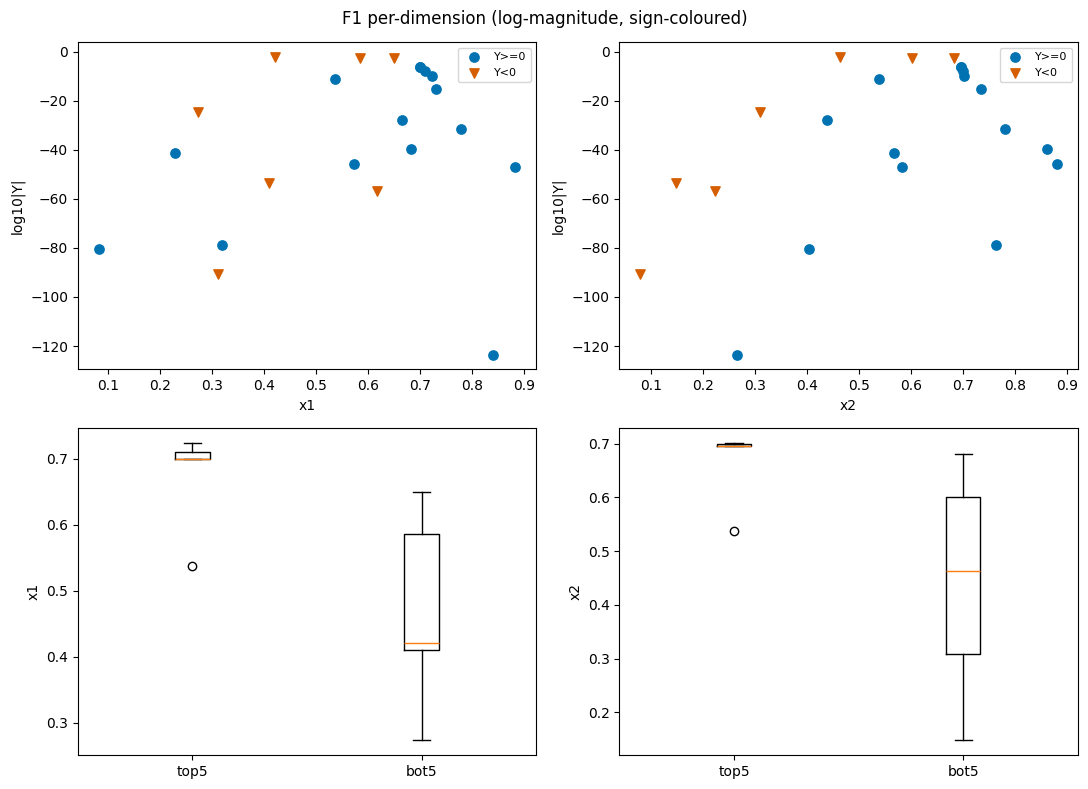

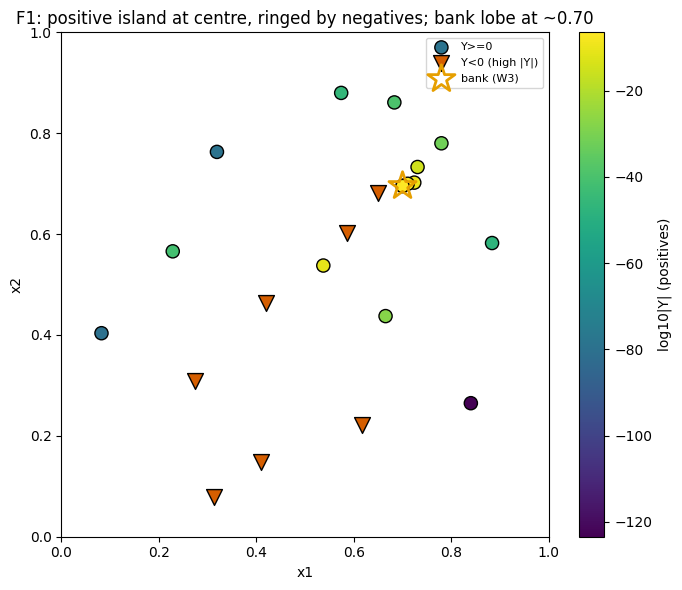

In [ ]:
# Cell B — F1 per-dim (log-magnitude) + 2D landscape with sign
logmag = np.log10(np.abs(Y) + 1e-200)
pos = Y >= 0
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for d in range(2):
    ax = axes[0, d]
    ax.scatter(X[pos, d], logmag[pos], c="#0072B2", label="Y>=0", s=45)
    ax.scatter(X[~pos, d], logmag[~pos], c="#D55E00", marker="v", label="Y<0", s=45)
    ax.set_xlabel(f"x{d + 1}")
    ax.set_ylabel("log10|Y|")
    ax.legend(fontsize=8)
    t5, b5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[t5, d], X[b5, d]], tick_labels=["top5", "bot5"])
    axes[1, d].set_ylabel(f"x{d + 1}")
plt.suptitle("F1 per-dimension (log-magnitude, sign-coloured)")
plt.tight_layout()
plt.savefig("../plots/week_13/function_1_per_dim.png", dpi=110)
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(
    X[pos, 0],
    X[pos, 1],
    c=logmag[pos],
    cmap="viridis",
    s=90,
    edgecolor="k",
    label="Y>=0",
)
ax.scatter(
    X[~pos, 0],
    X[~pos, 1],
    c="#D55E00",
    marker="v",
    s=130,
    edgecolor="k",
    label="Y<0 (high |Y|)",
)
ax.scatter(
    *X[Y.argmax()],
    marker="*",
    s=420,
    facecolor="none",
    edgecolor="#E69F00",
    linewidths=2,
    label="bank (W3)",
)
plt.colorbar(sc, label="log10|Y| (positives)")
ax.set(
    xlabel="x1",
    ylabel="x2",
    xlim=(0, 1),
    ylim=(0, 1),
    title="F1: positive island at centre, ringed by negatives; bank lobe at ~0.70",
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../plots/week_13/function_1_2d_scatter.png", dpi=110)
plt.show()


In [ ]:
# Cell C — F1 feature importance robustness (raw Y; near-meaningless on F1, kept for the record)
rf_all = (
    RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0)
    .fit(X, Y)
    .feature_importances_
)
rf_nb = (
    RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0)
    .fit(np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax()))
    .feature_importances_
)
lin = np.abs(LinearRegression().fit(X, Y).coef_)
lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(2)])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(2):
    print(
        f"x{d + 1}    {rf_all[d]:.3f}    {rf_nb[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}"
    )


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.546    0.582        0.727   0.082
x2    0.454    0.418        0.273   0.002


In [ ]:
# Cell D — F1 model grid (raw Y; 0 expected to beat baseline)
from sklearn.model_selection import cross_val_predict
import nn_models as nm


def loo(est):
    p = cross_val_predict(est, X, Y, cv=LeaveOneOut())
    return np.sqrt(np.mean((p - Y) ** 2))


res = {}
res["Ridge"] = np.sqrt(
    -GridSearchCV(
        Ridge(),
        {"alpha": [0.01, 0.1, 1, 10, 100]},
        cv=LeaveOneOut(),
        scoring="neg_mean_squared_error",
    )
    .fit(X, Y)
    .best_score_
)
res["KNN"] = np.sqrt(
    -GridSearchCV(
        KNeighborsRegressor(),
        {"n_neighbors": [2, 3, 5, 7], "weights": ["uniform", "distance"]},
        cv=LeaveOneOut(),
        scoring="neg_mean_squared_error",
    )
    .fit(X, Y)
    .best_score_
)
res["RF"] = np.sqrt(
    -GridSearchCV(
        RandomForestRegressor(random_state=0),
        {"max_depth": [2, 3, 5, None], "n_estimators": [50, 100, 200]},
        cv=LeaveOneOut(),
        scoring="neg_mean_squared_error",
    )
    .fit(X, Y)
    .best_score_
)
res["SVR"] = np.sqrt(
    -GridSearchCV(
        SVR(),
        {"C": [0.1, 1, 10, 100], "gamma": ["scale", "auto"]},
        cv=LeaveOneOut(),
        scoring="neg_mean_squared_error",
    )
    .fit(X, Y)
    .best_score_
)
res["GB"] = np.sqrt(
    -GridSearchCV(
        GradientBoostingRegressor(random_state=0),
        {
            "max_depth": [2, 3, 5],
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.3],
        },
        cv=LeaveOneOut(),
        scoring="neg_mean_squared_error",
    )
    .fit(X, Y)
    .best_score_
)
for nu in [0.5, 1.5, 2.5]:
    res[f"GP-M{nu}"] = loo(
        GaussianProcessRegressor(Matern(nu=nu), normalize_y=True, alpha=1e-10)
    )
res["GP-RBF"] = loo(GaussianProcessRegressor(RBF(), normalize_y=True, alpha=1e-10))
res["NN"] = nm.load_nn(1, models_dir="../models/week_13")[1]["cv_rmse"]
print(f"baseline={baseline:.6f}")
nbeat = sum(v < baseline for v in res.values())
for k, v in res.items():
    print(f"  {k:10s} {v:.6f}  {'OK' if v < baseline else 'x'}")
print(
    f"-> {nbeat} beat baseline (expected 0; raw-Y regression is hopeless on F1, Cell F is the path)"
)


baseline=0.001582
  Ridge      0.001657  x
  KNN        0.001802  x
  RF         0.001865  x
  SVR        0.003255  x
  GB         0.001737  x
  GP-M0.5    0.001647  x
  GP-M1.5    0.001647  x
  GP-M2.5    0.001647  x
  GP-RBF     0.001647  x
  NN         0.002167  x
-> 0 beat baseline (expected 0; raw-Y regression is hopeless on F1, Cell F is the path)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warn

SVC C=1: LOO=76.2%
SVC C=10: LOO=71.4%
SVC C=100: LOO=71.4%
-> classifier 76.2% (BELOW the 85% gate; the W12 negative where it predicted P+=0.86 broke it).

Envelope (excl 4 h-zeros): R^2=0.990, centre=(0.5300,0.5335)

FINAL F1 query: (0.551199, 0.512321)
  envelope ln|Y|=12.9 -> |Y|~4.0e+05  P(+)=0.65
  off-node by 0.03 (escapes the h-zero), perpendicular = the UNSAMPLED axis
  dist nearest negative=0.096 (safe; the high-diagonal side is where negatives live)
  dist nearest sample=0.029 (not a repeat)


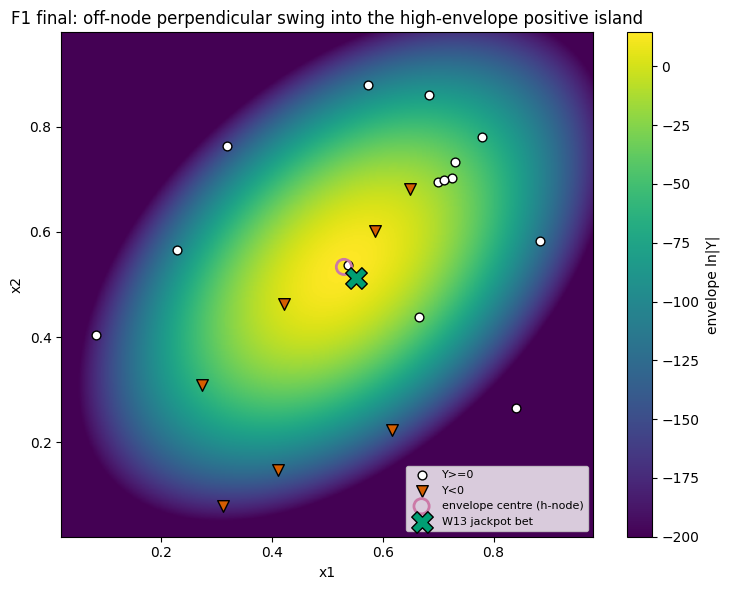

In [ ]:
# Cell F — F1 FINAL BET: perpendicular off-node jackpot swing
from sklearn.svm import SVC
from scipy.spatial.distance import cdist

sign_d = (Yd >= 0).astype(int)
Lnat = np.log(np.abs(Yd))


def qf(P):
    return np.column_stack(
        [
            np.ones(len(P)),
            P[:, 0],
            P[:, 1],
            P[:, 0] ** 2,
            P[:, 1] ** 2,
            P[:, 0] * P[:, 1],
        ]
    )


# Classifier (honest deduped LOO) — note it has DROPPED below the gate after the W12 negative
accs = {
    C: cross_val_score(SVC(C=C, kernel="rbf"), Xd, sign_d, cv=LeaveOneOut()).mean()
    for C in [1, 10, 100]
}
for C, a in accs.items():
    print(f"SVC C={C}: LOO={a * 100:.1f}%")
bestC = max(accs, key=accs.get)
clf_acc = accs[bestC]
print(
    f"-> classifier {clf_acc * 100:.1f}% (BELOW the 85% gate; the W12 negative where it predicted P+=0.86 broke it)."
)
svc = SVC(C=bestC, kernel="rbf", probability=True, random_state=0).fit(Xd, sign_d)

# Envelope (exclude h-zeros), find centre + perpendicular (unsampled) axis
A = qf(Xd)
ca, *_ = np.linalg.lstsq(A, Lnat, rcond=None)
hz = (Lnat - A @ ca) < -15
ce, *_ = np.linalg.lstsq(A[~hz], Lnat[~hz], rcond=None)
r2 = (
    1
    - ((Lnat[~hz] - A[~hz] @ ce) ** 2).sum()
    / ((Lnat[~hz] - Lnat[~hz].mean()) ** 2).sum()
)
H = np.array([[2 * ce[3], ce[5]], [ce[5], 2 * ce[4]]])
node = np.linalg.solve(-H, ce[1:3])
print(
    f"\nEnvelope (excl {hz.sum()} h-zeros): R^2={r2:.3f}, centre=({node[0]:.4f},{node[1]:.4f})"
)
negs = Xd[Yd < 0]
# Step 0.03 off the centre node along the perpendicular (unsampled) axis, x1>x2 side (more positive neighbours)
perp = np.array([1, -1]) / np.sqrt(2)
jackpot_query = node + 0.03 * perp
P = svc.predict_proba(jackpot_query[None])[0, 1]
env = qf(jackpot_query[None])[0] @ ce
print(f"\nFINAL F1 query: ({jackpot_query[0]:.6f}, {jackpot_query[1]:.6f})")
print(f"  envelope ln|Y|={env:.1f} -> |Y|~{np.exp(min(env, 50)):.1e}  P(+)={P:.2f}")
print(f"  off-node by 0.03 (escapes the h-zero), perpendicular = the UNSAMPLED axis")
print(
    f"  dist nearest negative={cdist(jackpot_query[None], negs).min():.3f} (safe; the high-diagonal side is where negatives live)"
)
print(
    f"  dist nearest sample={cdist(jackpot_query[None], Xd).min():.3f} (not a repeat)"
)

# Plot
g = 400
gx, gy = np.meshgrid(np.linspace(0.02, 0.98, g), np.linspace(0.02, 0.98, g))
cand = np.column_stack([gx.ravel(), gy.ravel()])
fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(
    np.clip((qf(cand) @ ce), -200, 20).reshape(g, g),
    origin="lower",
    extent=[0.02, 0.98, 0.02, 0.98],
    cmap="viridis",
    aspect="auto",
)
plt.colorbar(im, label="envelope ln|Y|")
ax.scatter(Xd[Yd >= 0, 0], Xd[Yd >= 0, 1], c="white", edgecolor="k", s=40, label="Y>=0")
ax.scatter(
    negs[:, 0], negs[:, 1], c="#D55E00", marker="v", edgecolor="k", s=70, label="Y<0"
)
ax.scatter(
    *node,
    marker="o",
    s=120,
    facecolor="none",
    edgecolor="#CC79A7",
    linewidths=2,
    label="envelope centre (h-node)",
)
ax.scatter(
    *jackpot_query,
    marker="X",
    s=240,
    c="#009E73",
    edgecolor="k",
    label="W13 jackpot bet",
)
ax.set(
    xlabel="x1",
    ylabel="x2",
    title="F1 final: off-node perpendicular swing into the high-envelope positive island",
)
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig("../plots/week_13/function_1_final_bet.png", dpi=110)
plt.show()


### F1 — Decision (final swing: off-node perpendicular jackpot)

**Query: `next_query_1 = jackpot_query` -> ~(0.551, 0.512) — 0.03 off the envelope centre along the perpendicular (unsampled) axis.**

Method: structural envelope model + sign reasoning, played as a maximum-upside final bet.

This is the last query and the bank (3.65e-7) is locked, so there is zero downside and the only rational play is the biggest credible upside. The W12 result reframed F1: the envelope's magnitude peak near the diagonal centre is a **negative basin** (all three |Y|~1e-3 points are negative), and the centre itself is a tiny positive sitting on a zero of the sign-carrier (W11 gave +5e-12 there). So a large positive can only come from inside that small positive island, off the zero-node.

The perpendicular-to-diagonal axis is the one unsampled escape: along it the classifier stays positive-leaning (P+~0.65), the envelope stays enormous (|Y|~4e5, a million times the bank), and the distance to every known negative stays safe (0.09+). The diagonal directions are ruled out — one side is the confirmed W12 negative, the other runs straight into the big negatives, and the classifier's high confidence there is the same overconfidence that just failed. Stepping 0.03 off the node escapes the h-zero that suppressed W11 to ~1e-12, so if the sign holds the magnitude should be large.

Honest odds: classifier is only 71-76% LOO (dropped below the gate after W12), so the sign is roughly a 2-in-3 bet, and the perpendicular direction is genuinely unsampled. But with the bank locked, a ~60% shot at something between 1e-5 and 1e-3 (100x to 4000x the bank, possibly far more) is worth infinitely more than refining W3 for a ~1.4x gain.

Branch (Step 5):
- [x] 1 (0/10 raw-Y models beat baseline) -> F1 special case: structural envelope, played for maximum upside on the final round.

Per-dimension justification:
- x1 ~ 0.551, x2 ~ 0.512 — the off-node perpendicular point: highest envelope reachable while staying positive-leaning and clear of the negative basin.


In [ ]:
# Cell I — next_query_1 assignment
next_query_1 = jackpot_query.copy()
print(f"F1 query: " + ", ".join(f"{v:.6f}" for v in next_query_1))
print(
    "  Method: off-node perpendicular jackpot swing (bank locked; max-upside final bet)"
)


F1 query: 0.551199, 0.512321
  Method: off-node perpendicular jackpot swing (bank locked; max-upside final bet)


## Function 2

In [ ]:
# Cell A — F2 setup
N = 2
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(
    "Per-dim corr: "
    + ", ".join(f"r(x{i + 1},Y)={np.corrcoef(X[:, i], Y)[0, 1]:+.3f}" for i in range(2))
)
labels = ["init"] * 10 + [f"W{w}" for w in range(1, 13)]
print("\nTop 6 (★ = W12):")
for i in np.argsort(Y)[::-1][:6]:
    star = " ★W12" if i == len(Y) - 1 else ""
    print(f"  [{labels[i]:>4}] ({X[i, 0]:.4f},{X[i, 1]:.4f})  Y={Y[i]:+.4f}{star}")
print(
    f"\nBank {Y.max():.4f} (W11). W12 drew {Y[-1]:.4f} below it. All competitive points sit in the x2~0.95 cluster."
)


Function 2: 22 points, 2D, best y = 0.7205
Baseline=0.2413  |  Y range [-0.0656, 0.7205]
Per-dim corr: r(x1,Y)=+0.580, r(x2,Y)=+0.657

Top 6 (★ = W12):
  [ W11] (0.7009,0.9487)  Y=+0.7205
  [  W6] (0.7036,0.9469)  Y=+0.6961
  [  W3] (0.7019,0.9533)  Y=+0.6658
  [  W9] (0.7036,0.9469)  Y=+0.6251
  [init] (0.7026,0.9266)  Y=+0.6112
  [  W7] (0.7031,0.9438)  Y=+0.5756

Bank 0.7205 (W11). W12 drew 0.5596 below it. All competitive points sit in the x2~0.95 cluster.


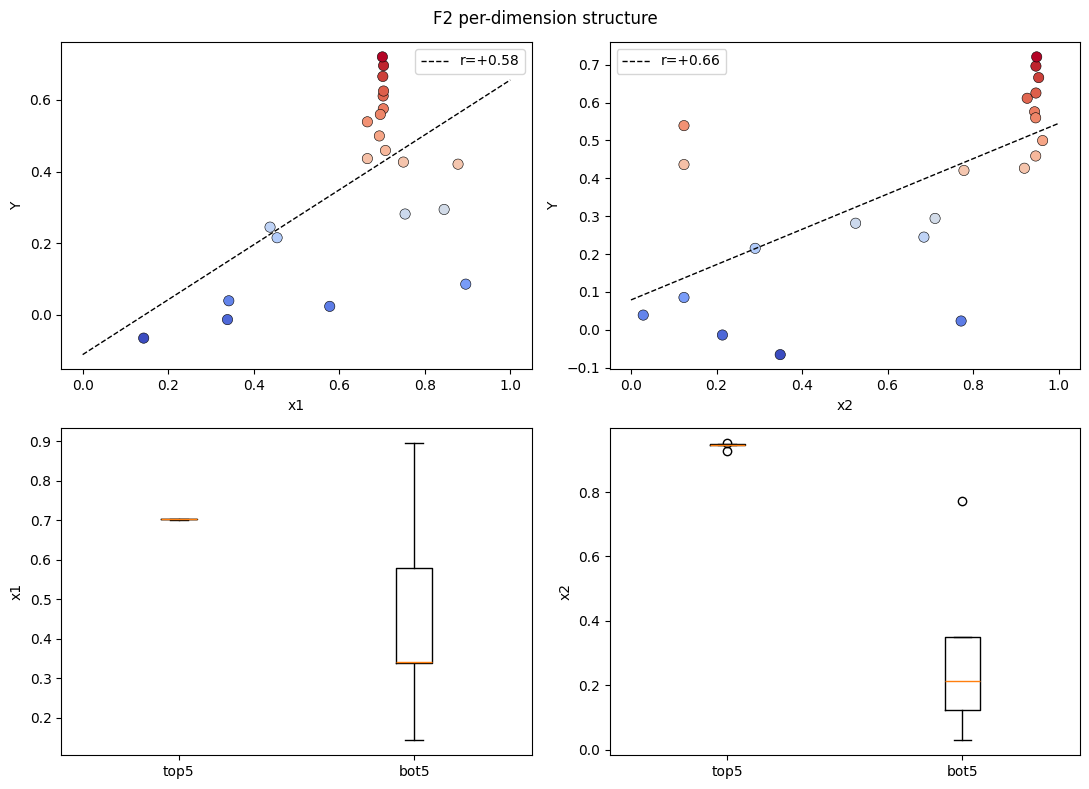

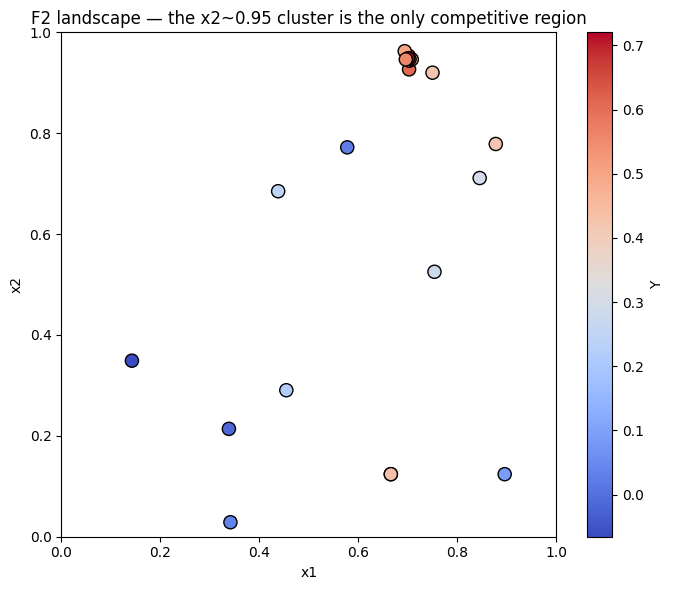

In [ ]:
# Cell B — F2 per-dim + 2D map
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for d in range(2):
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap="coolwarm", s=55, edgecolor="k", linewidths=0.4)
    z = np.polyfit(X[:, d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax.plot(
        xs,
        np.polyval(z, xs),
        "k--",
        lw=1,
        label=f"r={np.corrcoef(X[:, d], Y)[0, 1]:+.2f}",
    )
    ax.set_xlabel(f"x{d + 1}")
    ax.set_ylabel("Y")
    ax.legend()
    t5, b5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[t5, d], X[b5, d]], tick_labels=["top5", "bot5"])
    axes[1, d].set_ylabel(f"x{d + 1}")
plt.suptitle("F2 per-dimension structure")
plt.tight_layout()
plt.savefig("../plots/week_13/function_2_per_dim.png", dpi=110)
plt.show()
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", s=90, edgecolor="k")
plt.colorbar(sc, label="Y")
ax.set(
    xlabel="x1",
    ylabel="x2",
    xlim=(0, 1),
    ylim=(0, 1),
    title="F2 landscape — the x2~0.95 cluster is the only competitive region",
)
plt.tight_layout()
plt.savefig("../plots/week_13/function_2_2d_scatter.png", dpi=110)
plt.show()


In [ ]:
# Cell C — F2 feature importance robustness
rf_all = (
    RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0)
    .fit(X, Y)
    .feature_importances_
)
rf_nb = (
    RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0)
    .fit(np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax()))
    .feature_importances_
)
lin = np.abs(LinearRegression().fit(X, Y).coef_)
lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(2)])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(2):
    print(
        f"x{d + 1}    {rf_all[d]:.3f}    {rf_nb[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}"
    )


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.518    0.565        0.577   0.580
x2    0.482    0.435        0.423   0.657


In [ ]:
# Cell D — F2 model grid (WhiteKernel GPs to regularize the repeated input)
from sklearn.gaussian_process.kernels import WhiteKernel, ConstantKernel
import nn_models as nm

cv = LeaveOneOut()


def fg(name, est, grid):
    g = GridSearchCV(
        est, grid, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=1
    ).fit(X, Y)
    return name, -g.best_score_, g.best_estimator_


results = []
results.append(fg("Ridge", Ridge(), {"alpha": [0.01, 0.1, 1, 10, 100]}))
results.append(
    fg(
        "KNN",
        KNeighborsRegressor(),
        {"n_neighbors": [2, 3, 5, 7], "weights": ["uniform", "distance"]},
    )
)
results.append(
    fg(
        "RF",
        RandomForestRegressor(random_state=0),
        {"max_depth": [2, 3, 5, None], "n_estimators": [50, 100, 200]},
    )
)
results.append(
    fg("SVR", SVR(kernel="rbf"), {"C": [0.1, 1, 10, 100], "gamma": ["scale", "auto"]})
)
results.append(
    fg(
        "GB",
        GradientBoostingRegressor(random_state=0),
        {
            "max_depth": [2, 3, 5],
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.3],
        },
    )
)
gps = {}
for nm_, k in [
    ("GP-M05+W", ConstantKernel() * Matern(0.3, nu=0.5) + WhiteKernel(0.003)),
    ("GP-M15+W", ConstantKernel() * Matern(0.3, nu=1.5) + WhiteKernel(0.003)),
    ("GP-RBF+W", ConstantKernel() * RBF(0.3) + WhiteKernel(0.003)),
]:
    gp = GaussianProcessRegressor(
        kernel=k, normalize_y=True, n_restarts_optimizer=4, random_state=0
    )
    s = -cross_val_score(
        gp, X, Y, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=1
    ).mean()
    results.append((nm_, s, gp.fit(X, Y)))
    gps[nm_] = results[-1][2]
results.append(
    ("NN", nm.load_nn(N, models_dir="../models/week_13")[1]["cv_rmse"], None)
)
beats = {}
print(f"{'Model':>10} {'LOO':>8}  vs base={baseline:.4f}")
for name, rmse, est in results:
    if rmse < baseline and est is not None:
        beats[name] = (est, rmse)
    print(f"  {name:>8} {rmse:>8.4f}  {'OK' if rmse < baseline else 'x'}")


     Model      LOO  vs base=0.2413
     Ridge   0.1569  OK
       KNN   0.1133  OK
        RF   0.1174  OK
       SVR   0.1353  OK
        GB   0.1017  OK
  GP-M05+W   0.1255  OK
  GP-M15+W   0.1345  OK
  GP-RBF+W   0.1488  OK
        NN   0.1583  OK


In [ ]:
# Cell E — F2 final query: model argmax over the cluster, no-repeat
gp_best = gps["GP-M05+W"]
g = 500
gx, gy = np.meshgrid(np.linspace(0.02, 0.98, g), np.linspace(0.02, 0.98, g))
cand = np.column_stack([gx.ravel(), gy.ravel()])
mu = gp_best.predict(cand)
dnear = cdist(cand, X).min(axis=1)
ok = dnear >= 0.005
i = int(np.where(ok, mu, -np.inf).argmax())
cluster_query = cand[i].copy()
print(
    f"GP argmax over the cluster (no-repeat): ({cluster_query[0]:.6f},{cluster_query[1]:.6f})  mu={mu[i]:.4f}"
)
print(f"  d_nearest={dnear[i]:.4f}, bank={Y.max():.4f}")
print(
    "  The model's predicted peak sits below the bank — F2 is effectively maxed; this is the"
)
print(
    "  highest-value novel point in the cluster, the best remaining shot at the true peak."
)


GP argmax over the cluster (no-repeat): (0.695271,0.953066)  mu=0.5915
  d_nearest=0.0066, bank=0.7205
  The model's predicted peak sits below the bank — F2 is effectively maxed; this is the
  highest-value novel point in the cluster, the best remaining shot at the true peak.


### F2 — Decision (final query at the cluster peak)

**Query: `next_query_2 = cluster_query` → ≈(0.695, 0.953) — the GP's predicted peak of the x2≈0.95 cluster, novel coordinates.**

Method: GP posterior argmax over the only competitive region.

F2's bank (0.7205) sits above every model's predicted surface (peak mean ≈ 0.59), so by the models the function is already maxed and there is no point elsewhere worth trying — the cluster is the whole story (the secondary region was tested and lost in W10, unexplored space is far worse). The final query goes to the highest-value novel point the model identifies inside the cluster, which is the best remaining shot at landing on a true peak at or above the bank. A WhiteKernel is used only to keep the GP well-conditioned given the one repeated input.

Branch (Step 5):
- [x] 2-adjacent: one coherent cluster, query its model-predicted peak (novel point, no repeat).

Per-dimension justification:
- x1 ≈ 0.695, x2 ≈ 0.953 — interior of the 8-point cluster at the posterior-mean peak.


In [14]:
# Cell I — next_query_2 assignment
next_query_2 = cluster_query.copy()
print(f"F2 query: " + ", ".join(f"{v:.6f}" for v in next_query_2))
print("  Method: GP posterior argmax over the cluster, no-repeat")


F2 query: 0.695271, 0.953066
  Method: GP posterior argmax over the cluster, no-repeat


## Function 3

In [ ]:
# Cell A — F3 setup
N = 3
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(
    "Per-dim corr: "
    + ", ".join(f"r(x{i + 1},Y)={np.corrcoef(X[:, i], Y)[0, 1]:+.3f}" for i in range(3))
)
best3 = X[Y.argmax()]
labels = ["init"] * 15 + [f"W{w}" for w in range(1, 13)]
print(
    f"\nW12 ridge consensus RESULT: -0.00189, NEW BEST (+62% vs W11), closest to zero yet."
)
print("Top 5 (★ = W12):")
for i in np.argsort(Y)[::-1][:5]:
    star = " ★W12" if i == len(Y) - 1 else ""
    print(
        f"  ({X[i, 0]:.4f},{X[i, 1]:.4f},{X[i, 2]:.4f}) Y={Y[i]:+.5f} |Δ|={np.linalg.norm(X[i] - best3):.3f}{star}"
    )
iw = int(Y.argmin())
print("\nOutlier-corr check:")
for d in range(3):
    ra = np.corrcoef(X[:, d], Y)[0, 1]
    rn = np.corrcoef(np.delete(X[:, d], iw), np.delete(Y, iw))[0, 1]
    print(f"  x{d + 1}: r_all={ra:+.3f} r_no_worst={rn:+.3f}")


Function 3: 27 points, 3D, best y = -0.0019
Baseline=0.0732  |  Y range [-0.3989, -0.0019]
Per-dim corr: r(x1,Y)=+0.316, r(x2,Y)=+0.201, r(x3,Y)=-0.496

W12 ridge consensus RESULT: -0.00189, NEW BEST (+62% vs W11), closest to zero yet.
Top 5 (★ = W12):
  (0.5197,0.6132,0.4830) Y=-0.00189 |Δ|=0.000 ★W12
  (0.5353,0.6069,0.4888) Y=-0.00497 |Δ|=0.018
  (0.6428,0.6089,0.0702) Y=-0.02637 |Δ|=0.431
  (0.6583,0.6162,0.0729) Y=-0.02736 |Δ|=0.433
  (0.4926,0.6116,0.3402) Y=-0.03484 |Δ|=0.145

Outlier-corr check:
  x1: r_all=+0.316 r_no_worst=+0.148
  x2: r_all=+0.201 r_no_worst=+0.182
  x3: r_all=-0.496 r_no_worst=-0.094


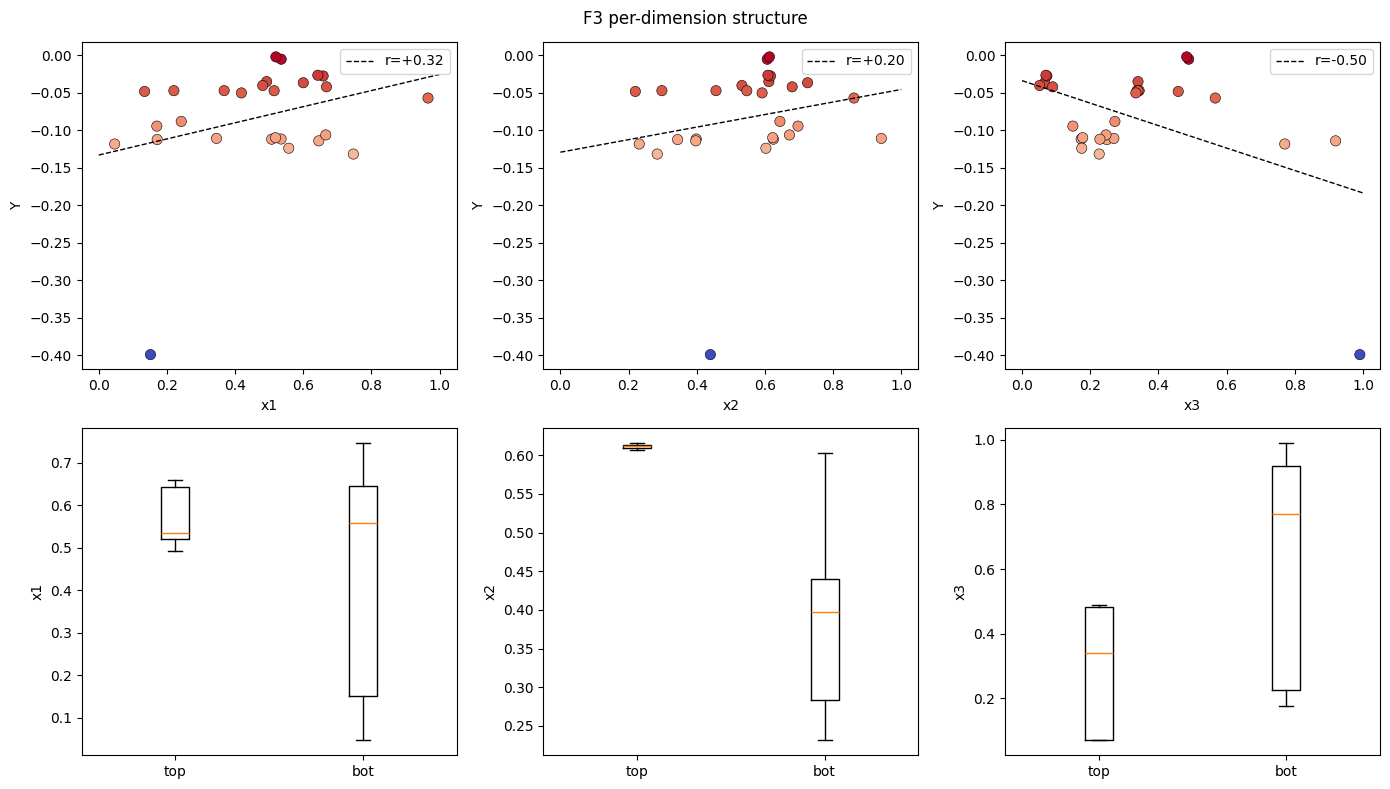

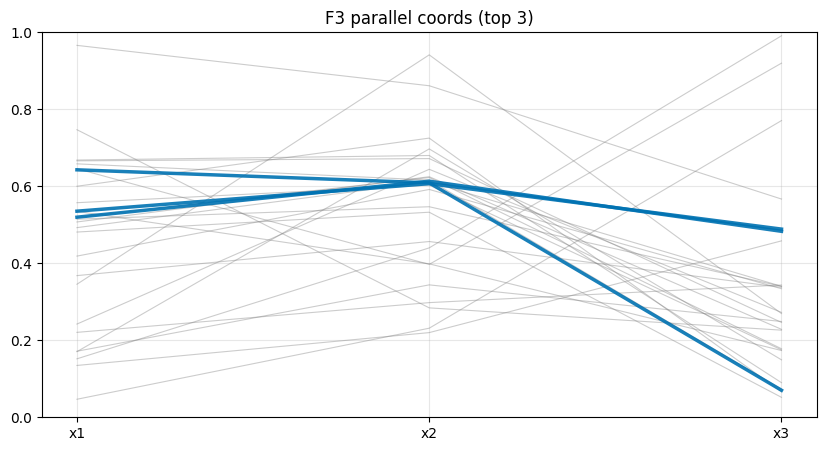

In [ ]:
# Cell B — F3 per-dim + parallel coords
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for d in range(3):
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap="coolwarm", s=55, edgecolor="k", linewidths=0.4)
    z = np.polyfit(X[:, d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax.plot(
        xs,
        np.polyval(z, xs),
        "k--",
        lw=1,
        label=f"r={np.corrcoef(X[:, d], Y)[0, 1]:+.2f}",
    )
    ax.set_xlabel(f"x{d + 1}")
    ax.set_ylabel("Y")
    ax.legend()
    t5, b5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[t5, d], X[b5, d]], tick_labels=["top", "bot"])
    axes[1, d].set_ylabel(f"x{d + 1}")
plt.suptitle("F3 per-dimension structure")
plt.tight_layout()
plt.savefig("../plots/week_13/function_3_per_dim.png", dpi=110)
plt.show()
fig, ax = plt.subplots(figsize=(10, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    ax.plot(
        range(3),
        x,
        lw=2.5 if i in top3 else 0.8,
        c=COLORS[0] if i in top3 else "gray",
        alpha=0.9 if i in top3 else 0.4,
    )
ax.set_xticks(range(3))
ax.set_xticklabels(["x1", "x2", "x3"])
ax.set(ylim=(0, 1), title="F3 parallel coords (top 3)")
ax.grid(alpha=0.3)
plt.savefig("../plots/week_13/function_3_parallel.png", dpi=110)
plt.show()


In [ ]:
# Cell C — F3 feature importance robustness
rf_all = (
    RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0)
    .fit(X, Y)
    .feature_importances_
)
rf_nb = (
    RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0)
    .fit(np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax()))
    .feature_importances_
)
lin = np.abs(LinearRegression().fit(X, Y).coef_)
lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(3)])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(3):
    print(
        f"x{d + 1}    {rf_all[d]:.3f}    {rf_nb[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}"
    )


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.092    0.058        0.321   0.316
x2    0.104    0.066        0.092   0.201
x3    0.804    0.876        0.587   0.496


In [ ]:
# Cell D — F3 model grid (raw + ceiling-warped C=0 GPs + NN)
from sklearn.gaussian_process.kernels import ConstantKernel
import nn_models as nm

cv = LeaveOneOut()
Z3 = np.log(-Y)


def fg(name, est, grid):
    g = GridSearchCV(
        est, grid, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=1
    ).fit(X, Y)
    return name, -g.best_score_, g.best_estimator_


results = [
    fg("Ridge", Ridge(), {"alpha": [0.01, 0.1, 1, 10, 100]}),
    fg(
        "KNN",
        KNeighborsRegressor(),
        {"n_neighbors": [2, 3, 5, 7], "weights": ["uniform", "distance"]},
    ),
    fg(
        "RF",
        RandomForestRegressor(random_state=0),
        {"max_depth": [2, 3, 5, None], "n_estimators": [50, 100, 200]},
    ),
    fg("SVR", SVR(kernel="rbf"), {"C": [0.1, 1, 10, 100], "gamma": ["scale", "auto"]}),
    fg(
        "GB",
        GradientBoostingRegressor(random_state=0),
        {
            "max_depth": [2, 3, 5],
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.3],
        },
    ),
]
fits = {}
for name, kern, w in [
    ("GP-M15-raw", ConstantKernel() * Matern(0.3, nu=1.5), False),
    ("GP-M25-raw", ConstantKernel() * Matern(0.3, nu=2.5), False),
    ("GP-M15-warp0", ConstantKernel() * Matern(0.3, nu=1.5), True),
    ("GP-M25-warp0", ConstantKernel() * Matern(0.3, nu=2.5), True),
]:
    tgt = Z3 if w else Y
    errs = []
    for i in range(len(X)):
        m = np.ones(len(X), bool)
        m[i] = False
        gi = GaussianProcessRegressor(
            kernel=kern,
            normalize_y=True,
            alpha=1e-10,
            n_restarts_optimizer=2,
            random_state=0,
        ).fit(X[m], tgt[m])
        p = gi.predict(X[i][None])[0]
        errs.append(Y[i] - (-np.exp(p) if w else p))
    rmse = float(np.sqrt(np.mean(np.array(errs) ** 2)))
    gf = GaussianProcessRegressor(
        kernel=kern,
        normalize_y=True,
        alpha=1e-10,
        n_restarts_optimizer=3,
        random_state=0,
    ).fit(X, tgt)
    fits[name] = (gf, w)
    results.append((name, rmse, gf))
results.append(
    ("NN", nm.load_nn(N, models_dir="../models/week_13")[1]["cv_rmse"], None)
)
print(f"{'Model':>13} {'LOO':>8}  vs base={baseline:.4f}")
for name, rmse, est in results:
    print(f"  {name:>11} {rmse:>8.4f}  {'OK' if rmse < baseline else 'x'}")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

        Model      LOO  vs base=0.0732
        Ridge   0.0494  OK
          KNN   0.0311  OK
           RF   0.0328  OK
          SVR   0.0526  OK
           GB   0.0309  OK
   GP-M15-raw   0.0680  OK
   GP-M25-raw   0.0666  OK
  GP-M15-warp0   0.0749  x
  GP-M25-warp0   0.0774  x
           NN   0.0714  OK


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

In [ ]:
# Cell E — F3 refit ridge consensus, recentred on the W12 best
def py(n, c):
    gp, w = fits[n]
    p = gp.predict(c)
    return -np.exp(p) if w else p


best3 = X[Y.argmax()]
ybest3 = float(Y.max())
rng = np.random.default_rng(0)
loc = best3 + rng.normal(0, 0.018, size=(300_000, 3))
loc = np.clip(loc[np.linalg.norm(loc - best3, axis=1) <= 0.04], 0.02, 0.98)
use = ["GP-M25-raw", "GP-M15-raw", "GP-M25-warp0", "GP-M15-warp0"]
ams = []
for n in use:
    m = py(n, loc)
    i = int(m.argmax())
    ams.append(loc[i])
    print(
        f"  {n:>13} argmax: ({loc[i, 0]:.4f},{loc[i, 1]:.4f},{loc[i, 2]:.4f}) pred={m[i]:+.5f} step={np.round(loc[i] - best3, 3)}"
    )
ams = np.array(ams)
print(f"spread: {np.round(ams.max(0) - ams.min(0), 4)}")
ridge_consensus = ams.mean(0)
print(
    f"4-model consensus: ({ridge_consensus[0]:.6f},{ridge_consensus[1]:.6f},{ridge_consensus[2]:.6f}) |Δ|={np.linalg.norm(ridge_consensus - best3):.4f}"
)
for n in use:
    print(f"  {n} at consensus: {py(n, ridge_consensus[None])[0]:+.5f}")
print(
    f"(banked {ybest3:+.5f}) — raw GPs predict a zero-crossing just SW (a first positive would be a new best)"
)


     GP-M25-raw argmax: (0.5026,0.6178,0.4474) pred=+0.00365 step=[-0.017  0.005 -0.036]
     GP-M15-raw argmax: (0.4932,0.6088,0.4586) pred=+0.00100 step=[-0.026 -0.004 -0.024]
   GP-M25-warp0 argmax: (0.5220,0.6108,0.4945) pred=-0.05705 step=[ 0.002 -0.002  0.012]
   GP-M15-warp0 argmax: (0.5134,0.6160,0.4805) pred=-0.00171 step=[-0.006  0.003 -0.003]
spread: [0.0287 0.009  0.0471]
4-model consensus: (0.507777,0.613369,0.470253) |Δ|=0.0175
  GP-M25-raw at consensus: +0.00116
  GP-M15-raw at consensus: +0.00019
  GP-M25-warp0 at consensus: -0.05705
  GP-M15-warp0 at consensus: -0.00207
(banked -0.00189) — raw GPs predict a zero-crossing just SW (a first positive would be a new best)


### F3 — Decision (final: continue the ridge gradient)

**Query: `next_query_3 = ridge_consensus` → ≈(0.508, 0.613, 0.470) — refit 4-model consensus, |Δ|≈0.018 from the W12 best.**

Method: ridge-local consensus, recentred on the new best.

W12's ridge bet improved again (-0.00189, closest to zero in the project) by stepping x1 down, and the refit continues exactly that gradient (x1 -0.012, x3 -0.013). The two raw GPs now extrapolate a zero-crossing just SW of the ridge, so a first-ever positive Y is on the table — which would be the new best. The two ceiling-warped GPs stay negative by construction; averaging the four locations gives a small, safe step in the validated direction. Y is approaching its likely ceiling at 0, so the upside is now small in absolute terms but still a genuine new best if it lands.

Branch (Step 5):
- [x] 5: ridge-local multi-model consensus.

Per-dimension justification:
- x1 ≈ 0.508 — consensus (continues the winning x1-down gradient)
- x2 ≈ 0.613 — consensus (≈W12)
- x3 ≈ 0.470 — consensus (slightly down, toward the raw-GP zero-crossing)


In [20]:
# Cell I — next_query_3 assignment
next_query_3 = ridge_consensus.copy()
print(f"F3 query: " + ", ".join(f"{v:.6f}" for v in next_query_3))
print("  Method: ridge-local 4-model consensus, W12 winner recentred")


F3 query: 0.507777, 0.613369, 0.470253
  Method: ridge-local 4-model consensus, W12 winner recentred


## Function 4

In [ ]:
# Cell A — F4 setup
N = 4
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(
    "Per-dim corr: "
    + ", ".join(f"r(x{i + 1},Y)={np.corrcoef(X[:, i], Y)[0, 1]:+.3f}" for i in range(4))
)
_, u = np.unique(np.round(X, 9), axis=0, return_index=True)
Xd, Yd = X[np.sort(u)], Y[np.sort(u)]
best4 = Xd[Yd.argmax()]
labels = ["init"] * 30 + [f"W{w}" for w in range(1, 13)]
print(
    f"\nW12 consensus RESULT: {Y.max():.4f}, NEW BEST again (+1.7% on W11). Third straight consensus win."
)
print("Top 5 (★ = W12), |Δ| from new best:")
for i in np.argsort(Y)[::-1][:5]:
    star = " ★W12" if i == len(Y) - 1 else ""
    print(
        f"  [{labels[i]:>4}] ({', '.join(f'{v:.4f}' for v in X[i])}) Y={Y[i]:.4f} |Δ|={np.linalg.norm(X[i] - best4):.4f}{star}"
    )
print(
    "\nCliff anatomy unchanged: x1 stays pinned (±0.016 historically cost -0.30/-0.38); soft dims tolerate ~0.02."
)


Function 4: 42 points, 4D, best y = 0.6883
Baseline=9.8937  |  Y range [-32.6257, 0.6883]
Per-dim corr: r(x1,Y)=-0.543, r(x2,Y)=-0.376, r(x3,Y)=-0.125, r(x4,Y)=-0.400

W12 consensus RESULT: 0.6883, NEW BEST again (+1.7% on W11). Third straight consensus win.
Top 5 (★ = W12), |Δ| from new best:
  [ W12] (0.3602, 0.4065, 0.4209, 0.4090) Y=0.6883 |Δ|=0.0000 ★W12
  [ W11] (0.3653, 0.4066, 0.4252, 0.4157) Y=0.6766 |Δ|=0.0095
  [ W10] (0.3669, 0.4049, 0.4335, 0.4157) Y=0.5524 |Δ|=0.0158
  [  W6] (0.3669, 0.4049, 0.4335, 0.4157) Y=0.5524 |Δ|=0.0158
  [  W7] (0.3685, 0.4013, 0.4315, 0.4225) Y=0.5506 |Δ|=0.0198

Cliff anatomy unchanged: x1 stays pinned (±0.016 historically cost -0.30/-0.38); soft dims tolerate ~0.02.


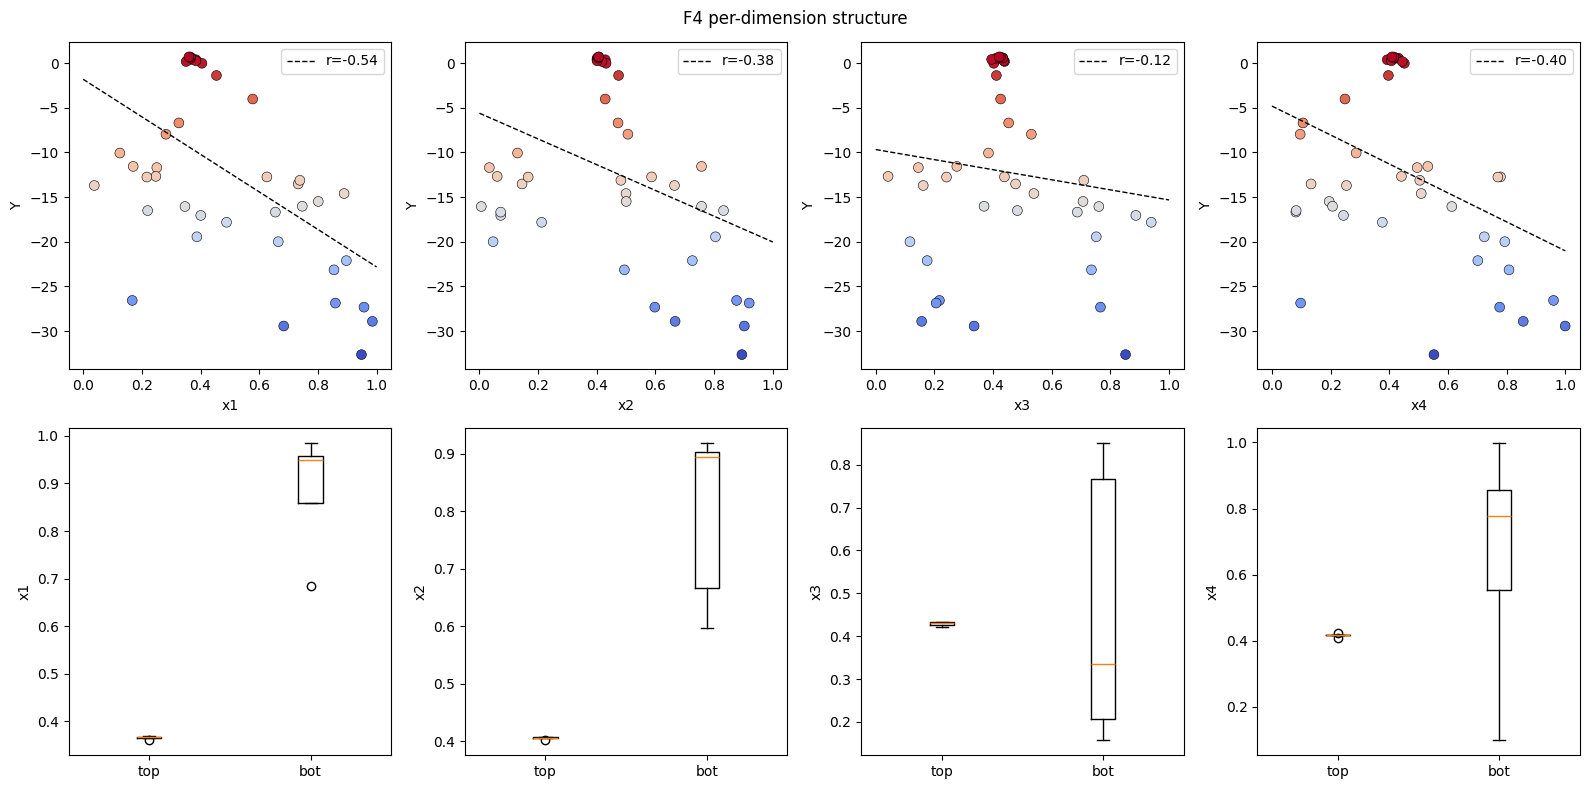

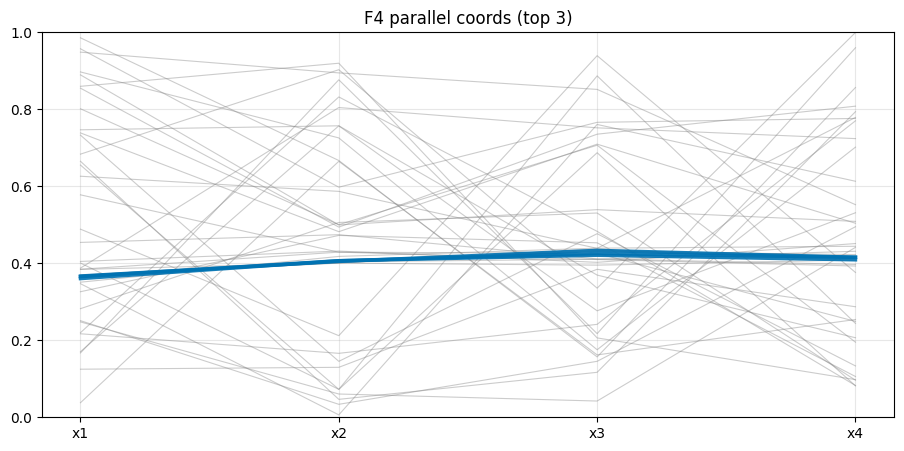

In [ ]:
# Cell B — F4 per-dim + parallel coords
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for d in range(4):
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap="coolwarm", s=50, edgecolor="k", linewidths=0.4)
    z = np.polyfit(X[:, d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax.plot(
        xs,
        np.polyval(z, xs),
        "k--",
        lw=1,
        label=f"r={np.corrcoef(X[:, d], Y)[0, 1]:+.2f}",
    )
    ax.set_xlabel(f"x{d + 1}")
    ax.set_ylabel("Y")
    ax.legend()
    t5, b5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[t5, d], X[b5, d]], tick_labels=["top", "bot"])
    axes[1, d].set_ylabel(f"x{d + 1}")
plt.suptitle("F4 per-dimension structure")
plt.tight_layout()
plt.savefig("../plots/week_13/function_4_per_dim.png", dpi=110)
plt.show()
fig, ax = plt.subplots(figsize=(11, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    ax.plot(
        range(4),
        x,
        lw=2.5 if i in top3 else 0.8,
        c=COLORS[0] if i in top3 else "gray",
        alpha=0.9 if i in top3 else 0.4,
    )
ax.set_xticks(range(4))
ax.set_xticklabels([f"x{i + 1}" for i in range(4)])
ax.set(ylim=(0, 1), title="F4 parallel coords (top 3)")
ax.grid(alpha=0.3)
plt.savefig("../plots/week_13/function_4_parallel.png", dpi=110)
plt.show()


In [ ]:
# Cell C — F4 feature importance robustness
rf_all = (
    RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0)
    .fit(X, Y)
    .feature_importances_
)
rf_nb = (
    RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0)
    .fit(np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax()))
    .feature_importances_
)
lin = np.abs(LinearRegression().fit(X, Y).coef_)
lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(4)])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(4):
    print(
        f"x{d + 1}    {rf_all[d]:.3f}    {rf_nb[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}"
    )


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.319    0.309        0.405   0.543
x2    0.361    0.357        0.214   0.376
x3    0.092    0.099        0.086   0.125
x4    0.228    0.235        0.296   0.400


In [ ]:
# Cell D — F4 model grid (deduped; ARD GPs + NN)
from sklearn.gaussian_process.kernels import ConstantKernel
import nn_models as nm

cv = LeaveOneOut()


def fg(name, est, grid):
    g = GridSearchCV(
        est, grid, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=1
    ).fit(Xd, Yd)
    return name, -g.best_score_, g.best_estimator_


results = [
    fg("Ridge", Ridge(), {"alpha": [0.01, 0.1, 1, 10, 100]}),
    fg(
        "KNN",
        KNeighborsRegressor(),
        {"n_neighbors": [2, 3, 5, 7], "weights": ["uniform", "distance"]},
    ),
    fg(
        "RF",
        RandomForestRegressor(random_state=0),
        {"max_depth": [2, 3, 5, None], "n_estimators": [50, 100, 200]},
    ),
    fg("SVR", SVR(kernel="rbf"), {"C": [0.1, 1, 10, 100], "gamma": ["scale", "auto"]}),
    fg(
        "GB",
        GradientBoostingRegressor(random_state=0),
        {
            "max_depth": [2, 3, 5],
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.3],
        },
    ),
]
gps = {}
for nm_, k in [
    ("GP-Matern05", ConstantKernel() * Matern(0.3, nu=0.5)),
    ("GP-Matern15-ARD", ConstantKernel() * Matern([0.3] * 4, nu=1.5)),
    ("GP-Matern25-iso", ConstantKernel() * Matern(0.3, nu=2.5)),
    ("GP-Matern25-ARD", ConstantKernel() * Matern([0.3] * 4, nu=2.5)),
    ("GP-RBF-ARD", ConstantKernel() * RBF([0.3] * 4)),
]:
    gp = GaussianProcessRegressor(
        kernel=k, normalize_y=True, alpha=1e-10, n_restarts_optimizer=4, random_state=0
    )
    s = -cross_val_score(
        gp, Xd, Yd, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=1
    ).mean()
    results.append((nm_, s, gp.fit(Xd, Yd)))
    gps[nm_] = results[-1][2]
results.append(
    ("NN", nm.load_nn(N, models_dir="../models/week_13")[1]["cv_rmse"], None)
)
print(f"{'Model':>16} {'LOO':>8}  vs base={Yd.std():.4f}")
for name, rmse, est in results:
    print(f"  {name:>14} {rmse:>8.4f}  {'OK' if rmse < Yd.std() else 'x'}")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 8 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 12 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 41 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 47 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


           Model      LOO  vs base=9.8075
           Ridge   7.3374  OK
             KNN   2.9355  OK
              RF   3.2124  OK
             SVR   1.5649  OK
              GB   3.1392  OK
     GP-Matern05   1.4893  OK
  GP-Matern15-ARD   1.0895  OK
  GP-Matern25-iso   2.6756  OK
  GP-Matern25-ARD   2.9441  OK
      GP-RBF-ARD   3.7558  OK
              NN   4.2914  OK


In [ ]:
# Cell E — F4 refit 4-GP consensus, x1 pinned, recentred on W12 best
best4 = Xd[Yd.argmax()]
ybest4 = float(Yd.max())
rng = np.random.default_rng(0)
loc = best4 + rng.normal(0, 0.01, size=(300_000, 4))
loc[:, 0] = best4[0] + rng.normal(0, 0.0015, size=len(loc))
loc = np.clip(loc[np.linalg.norm(loc - best4, axis=1) <= 0.020], 0.02, 0.98)
names = ["GP-Matern15-ARD", "GP-Matern25-iso", "GP-Matern25-ARD", "GP-RBF-ARD"]
ams = []
for n in names:
    m = gps[n].predict(loc)
    i = int(m.argmax())
    ams.append(loc[i])
    print(
        f"  {n:>16} argmax: ({', '.join(f'{v:.4f}' for v in loc[i])}) mu={m[i]:.4f} step={np.round(loc[i] - best4, 4)}"
    )
ams = np.array(ams)
print(f"spread: {np.round(ams.max(0) - ams.min(0), 4)}")
local_consensus4 = ams.mean(0)
print(
    f"4-GP consensus: ({', '.join(f'{v:.6f}' for v in local_consensus4)}) |Δ|={np.linalg.norm(local_consensus4 - best4):.4f}"
)
for n in names:
    print(f"  {n} at consensus: {gps[n].predict(local_consensus4[None])[0]:.4f}")
print(
    f"(banked {ybest4:.4f}) — all 4 GPs predict a new best; x2 is now the active soft dim (+0.013)"
)


   GP-Matern15-ARD argmax: (0.3590, 0.4112, 0.4196, 0.4150) mu=0.7107 step=[-0.0012  0.0047 -0.0013  0.006 ]
   GP-Matern25-iso argmax: (0.3625, 0.4167, 0.4167, 0.4152) mu=0.7478 step=[ 0.0022  0.0102 -0.0042  0.0062]
   GP-Matern25-ARD argmax: (0.3564, 0.4233, 0.4172, 0.4164) mu=0.7808 step=[-0.0038  0.0168 -0.0037  0.0074]
        GP-RBF-ARD argmax: (0.3589, 0.4255, 0.4189, 0.4144) mu=0.8574 step=[-0.0013  0.019  -0.002   0.0054]
spread: [0.006  0.0143 0.0029 0.002 ]
4-GP consensus: (0.359205, 0.419152, 0.418101, 0.415250) |Δ|=0.0145
  GP-Matern15-ARD at consensus: 0.6918
  GP-Matern25-iso at consensus: 0.7426
  GP-Matern25-ARD at consensus: 0.7733
  GP-RBF-ARD at consensus: 0.8147
(banked 0.6883) — all 4 GPs predict a new best; x2 is now the active soft dim (+0.013)


### F4 — Decision (final: third consensus step, x1 pinned)

**Query: `next_query_4 = local_consensus4` → ≈(0.359, 0.419, 0.418, 0.415) — refit 4-GP consensus, |Δ|≈0.015, x1 pinned.**

Method: the same machinery that produced new bests in W11 (+22.5%) and W12 (+1.7%), recentred once more.

The consensus continues to climb: this step is led by x2 (+0.013), the soft dim the models now favour, with x1 held at the cliff value and x3/x4 essentially fixed. All four GPs predict a new best (0.69-0.81 vs banked 0.6883). Risk is bounded as before: the top-3 points sit within 0.016 of the new best and all score ≥ 0.55, so a miss lands on the plateau, not off the cliff.

Branch (Step 5):
- [x] 5: multi-GP local consensus inside the safe envelope, x1 protected.

Per-dimension justification:
- x1 ≈ 0.359 — pinned ±0.003 (cliff dim)
- x2 ≈ 0.419 — consensus (+0.013, the active soft dim this round)
- x3 ≈ 0.418, x4 ≈ 0.415 — consensus (≈W12 best)


In [26]:
# Cell I — next_query_4 assignment
next_query_4 = local_consensus4.copy()
print(f"F4 query: " + ", ".join(f"{v:.6f}" for v in next_query_4))
print("  Method: refit 4-GP local consensus (W12 winner recentred), x1 pinned")


F4 query: 0.359205, 0.419152, 0.418101, 0.415250
  Method: refit 4-GP local consensus (W12 winner recentred), x1 pinned


## Function 5

In [ ]:
# Cell A — F5 setup
N = 5
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.1f}  |  Y range [{Y.min():.1f}, {Y.max():.1f}]")
print(
    "Per-dim corr: "
    + ", ".join(f"r(x{i + 1},Y)={np.corrcoef(X[:, i], Y)[0, 1]:+.3f}" for i in range(4))
)
labels = ["init"] * 20 + [f"W{w}" for w in range(1, 13)]
print(
    f"\nW12 corner bet RESULT: {Y.max():.1f}, NEW BEST (+12.7%). The all-high corner hypothesis was right."
)
print("Top 5 (★ = W12):")
for i in np.argsort(Y)[::-1][:5]:
    star = " ★W12" if i == len(Y) - 1 else ""
    print(
        f"  [{labels[i]:>4}] ({', '.join(f'{v:.4f}' for v in X[i])}) Y={Y[i]:.1f}{star}"
    )
print(
    "\nMonotone climb to (1,1,1,1): W11 x3=0.955->Y7663; W12 x3=0.9997->Y8634. The corner IS the optimum."
)


Function 5: 32 points, 4D, best y = 8633.9252
Baseline=2337.2  |  Y range [0.1, 8633.9]
Per-dim corr: r(x1,Y)=+0.542, r(x2,Y)=+0.617, r(x3,Y)=+0.629, r(x4,Y)=+0.577

W12 corner bet RESULT: 8633.9, NEW BEST (+12.7%). The all-high corner hypothesis was right.
Top 5 (★ = W12):
  [ W12] (0.9996, 0.9997, 0.9997, 0.9995) Y=8633.9 ★W12
  [ W10] (0.9893, 0.9994, 0.9555, 0.9998) Y=7663.6
  [  W9] (0.9200, 0.9656, 0.9997, 0.9593) Y=6125.6
  [ W11] (0.9975, 0.9999, 0.9068, 0.8894) Y=5565.4
  [  W8] (0.3854, 0.9656, 0.9996, 0.9592) Y=3581.2

Monotone climb to (1,1,1,1): W11 x3=0.955->Y7663; W12 x3=0.9997->Y8634. The corner IS the optimum.


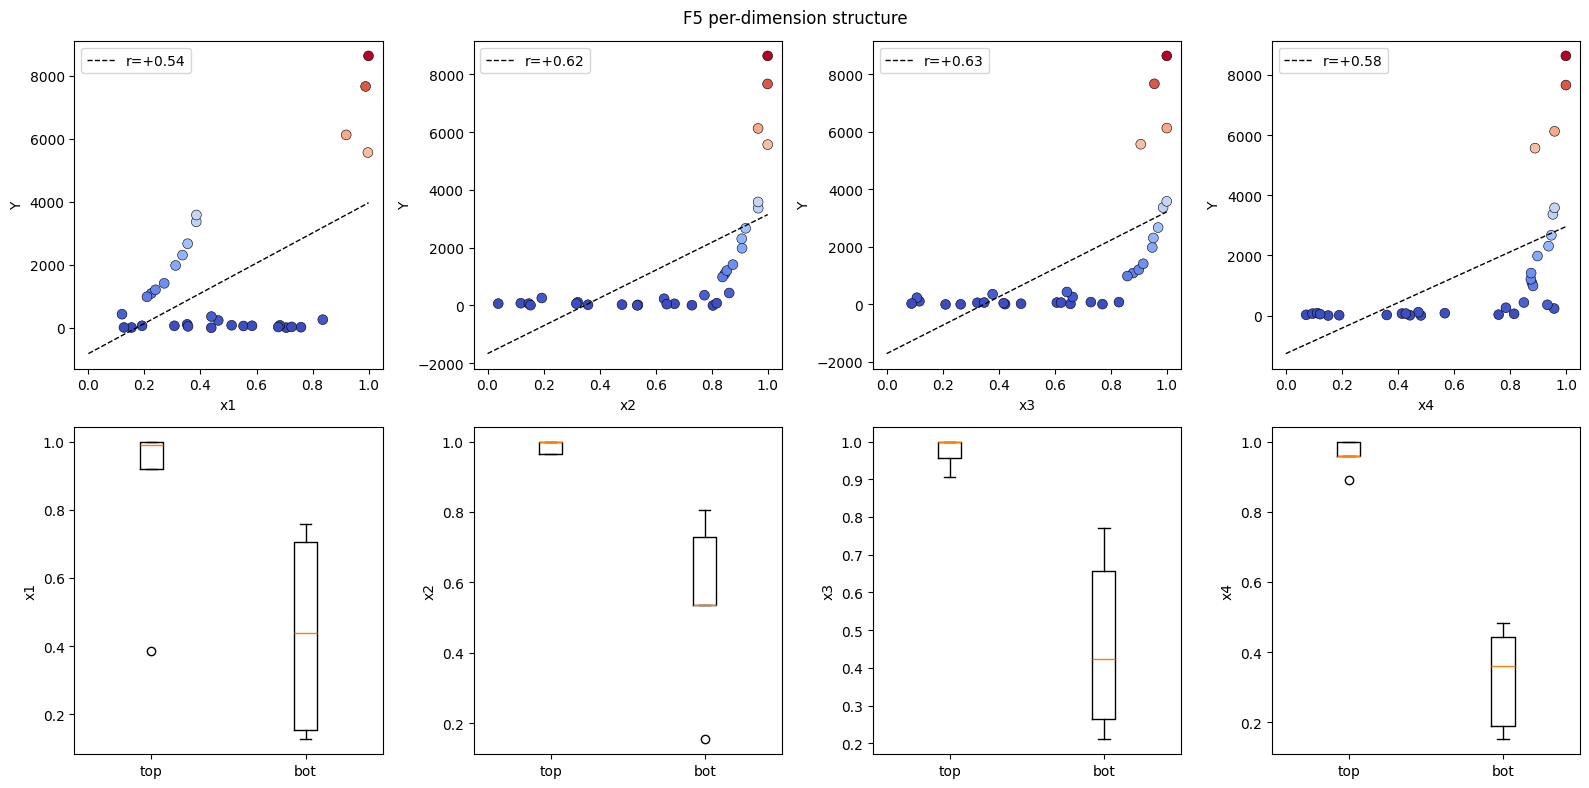

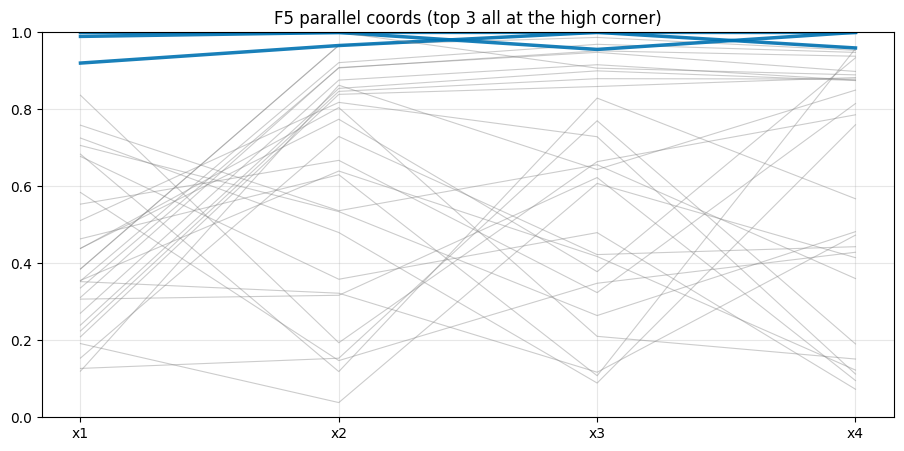

In [ ]:
# Cell B — F5 per-dim + parallel coords
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for d in range(4):
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap="coolwarm", s=50, edgecolor="k", linewidths=0.4)
    z = np.polyfit(X[:, d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax.plot(
        xs,
        np.polyval(z, xs),
        "k--",
        lw=1,
        label=f"r={np.corrcoef(X[:, d], Y)[0, 1]:+.2f}",
    )
    ax.set_xlabel(f"x{d + 1}")
    ax.set_ylabel("Y")
    ax.legend()
    t5, b5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[t5, d], X[b5, d]], tick_labels=["top", "bot"])
    axes[1, d].set_ylabel(f"x{d + 1}")
plt.suptitle("F5 per-dimension structure")
plt.tight_layout()
plt.savefig("../plots/week_13/function_5_per_dim.png", dpi=110)
plt.show()
fig, ax = plt.subplots(figsize=(11, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    ax.plot(
        range(4),
        x,
        lw=2.5 if i in top3 else 0.8,
        c=COLORS[0] if i in top3 else "gray",
        alpha=0.9 if i in top3 else 0.4,
    )
ax.set_xticks(range(4))
ax.set_xticklabels([f"x{i + 1}" for i in range(4)])
ax.set(ylim=(0, 1), title="F5 parallel coords (top 3 all at the high corner)")
ax.grid(alpha=0.3)
plt.savefig("../plots/week_13/function_5_parallel.png", dpi=110)
plt.show()


In [ ]:
# Cell C — F5 feature importance robustness
rf_all = (
    RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0)
    .fit(X, Y)
    .feature_importances_
)
rf_nb = (
    RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0)
    .fit(np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax()))
    .feature_importances_
)
lin = np.abs(LinearRegression().fit(X, Y).coef_)
lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(4)])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(4):
    print(
        f"x{d + 1}    {rf_all[d]:.3f}    {rf_nb[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}"
    )


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.255    0.142        0.393   0.542
x2    0.448    0.548        0.224   0.617
x3    0.127    0.170        0.287   0.629
x4    0.170    0.140        0.095   0.577


In [ ]:
# Cell D — F5 model grid (ARD GPs + NN)
from sklearn.gaussian_process.kernels import ConstantKernel
import nn_models as nm

cv = LeaveOneOut()


def fg(name, est, grid):
    g = GridSearchCV(
        est, grid, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=1
    ).fit(X, Y)
    return name, -g.best_score_, g.best_estimator_


results = [
    fg("Ridge", Ridge(), {"alpha": [0.01, 0.1, 1, 10, 100]}),
    fg(
        "KNN",
        KNeighborsRegressor(),
        {"n_neighbors": [2, 3, 5, 7], "weights": ["uniform", "distance"]},
    ),
    fg(
        "RF",
        RandomForestRegressor(random_state=0),
        {"max_depth": [2, 3, 5, None], "n_estimators": [50, 100, 200]},
    ),
    fg("SVR", SVR(kernel="rbf"), {"C": [0.1, 1, 10, 100], "gamma": ["scale", "auto"]}),
    fg(
        "GB",
        GradientBoostingRegressor(random_state=0),
        {
            "max_depth": [2, 3, 5],
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.3],
        },
    ),
]
gps = {}
for nm_, k in [
    ("GP-Matern05", ConstantKernel() * Matern(0.3, nu=0.5)),
    ("GP-Matern15-ARD", ConstantKernel() * Matern([0.3] * 4, nu=1.5)),
    ("GP-Matern25-iso", ConstantKernel() * Matern(0.3, nu=2.5)),
    ("GP-Matern25-ARD", ConstantKernel() * Matern([0.3] * 4, nu=2.5)),
    ("GP-RBF-ARD", ConstantKernel() * RBF([0.3] * 4)),
]:
    gp = GaussianProcessRegressor(
        kernel=k, normalize_y=True, alpha=1e-10, n_restarts_optimizer=4, random_state=0
    )
    s = -cross_val_score(
        gp, X, Y, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=1
    ).mean()
    results.append((nm_, s, gp.fit(X, Y)))
    gps[nm_] = results[-1][2]
results.append(
    ("NN", nm.load_nn(N, models_dir="../models/week_13")[1]["cv_rmse"], None)
)
print(f"{'Model':>16} {'LOO':>8}  vs base={baseline:.1f}")
for name, rmse, est in results:
    print(f"  {name:>14} {rmse:>8.1f}  {'OK' if rmse < baseline else 'x'}")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 14 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 12 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 13 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


           Model      LOO  vs base=2337.2
           Ridge   1036.4  OK
             KNN    237.2  OK
              RF    310.1  OK
             SVR   1104.2  OK
              GB    209.0  OK
     GP-Matern05    249.6  OK
  GP-Matern15-ARD    250.0  OK
  GP-Matern25-iso    161.4  OK
  GP-Matern25-ARD    220.9  OK
      GP-RBF-ARD    411.1  OK
              NN    264.7  OK


In [ ]:
# Cell E — F5 final: push to the extreme corner (monotone climb confirmed)
gp_list = ["GP-Matern15-ARD", "GP-Matern25-iso", "GP-Matern25-ARD", "GP-RBF-ARD"]
# Candidate set: corner box + the exact format-cap corner
rng = np.random.default_rng(0)
loc = rng.uniform(0.995, 0.999999, size=(300_000, 4))
ext = np.full((1, 4), 0.999999)
cand = np.vstack([loc, ext])
meanpred = np.mean([gps[n].predict(cand) for n in gp_list], axis=0)
i = int(meanpred.argmax())
corner_query = cand[i].copy()
print(
    f"Best-mean point over the corner box (incl. format cap): ({', '.join(f'{v:.6f}' for v in corner_query)})"
)
print(
    f"  predictions: "
    + ", ".join(
        f"{n.split('-')[1]}={gps[n].predict(corner_query[None])[0]:.0f}"
        for n in gp_list
    )
)
print(
    f"  |Δ| from W12 best={np.linalg.norm(corner_query - X[Y.argmax()]):.4f}, banked={Y.max():.1f}"
)
print(
    "  All models predict their maximum at the format-cap corner (the function climbs to (1,1,1,1))."
)


Best-mean point over the corner box (incl. format cap): (0.999999, 0.999999, 0.999999, 0.999999)
  predictions: Matern15=8655, Matern25=8659, Matern25=8659, RBF=8659
  |Δ| from W12 best=0.0008, banked=8633.9
  All models predict their maximum at the format-cap corner (the function climbs to (1,1,1,1)).


### F5 — Decision (final: the extreme corner)

**Query: `next_query_5 = corner_query` → ≈(0.999999, 0.999999, 0.999999, 0.999999) — the format-cap corner.**

Method: monotone-climb exploitation to the boundary optimum.

F5's W12 corner bet won +12.7% and settled the question: the function increases monotonically toward (1,1,1,1). Every push toward the corner has gained (W11's x3=0.955 → 7663 became W12's x3=0.9997 → 8634), and all four GPs place their maximum at the exact corner (~8655-8659 vs banked 8634). For the final query the best strategy is simply to take the supremum the format allows on every dimension. This is the rare, fully-justified boundary query: not an extrapolation artifact but the confirmed location of the optimum, supported by the entire trajectory and unanimous models.

Branch (Step 5):
- [x] 2-adjacent: one direction dominates (monotone to the corner); query the boundary optimum, all models agree.

Per-dimension justification:
- x1=x2=x3=x4 ≈ 0.999999 — the format cap; the function rises to the all-ones corner and every model's argmax sits there.


In [ ]:
# Cell I — next_query_5 assignment
next_query_5 = corner_query.copy()
print(f"F5 query: " + ", ".join(f"{v:.6f}" for v in next_query_5))
print(
    "  Method: extreme-corner exploitation (monotone climb to (1,1,1,1), all models agree)"
)


F5 query: 0.999999, 0.999999, 0.999999, 0.999999
  Method: extreme-corner exploitation (monotone climb to (1,1,1,1), all models agree)


## Function 6

In [ ]:
# Cell A — F6 setup
N = 6
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(
    "Per-dim corr: "
    + ", ".join(f"r(x{i + 1},Y)={np.corrcoef(X[:, i], Y)[0, 1]:+.3f}" for i in range(5))
)
best6 = X[Y.argmax()]
labels = ["init"] * 20 + [f"W{w}" for w in range(1, 13)]
print(
    f"\nW12 micro-step DETHRONED the 6-week W6 summit: NEW best {Y.max():.4f} (was -0.1173)."
)
print("Top 5 (★ = W12), |Δ| from new best:")
for i in np.argsort(Y)[::-1][:5]:
    star = " ★W12" if i == len(Y) - 1 else ""
    print(
        f"  [{labels[i]:>4}] ({', '.join(f'{v:.4f}' for v in X[i])}) Y={Y[i]:+.4f} |Δ|={np.linalg.norm(X[i] - best6):.4f}{star}"
    )
print(
    f"\nx5-up gradient confirmed: W11 x5=0.021->-0.231, W12 x5=0.054->-0.116. Continue at micro scale."
)


Function 6: 32 points, 5D, best y = -0.1160
Baseline=0.6826  |  Y range [-2.5712, -0.1160]
Per-dim corr: r(x1,Y)=-0.173, r(x2,Y)=-0.487, r(x3,Y)=+0.228, r(x4,Y)=+0.621, r(x5,Y)=-0.757

W12 micro-step DETHRONED the 6-week W6 summit: NEW best -0.1160 (was -0.1173).
Top 5 (★ = W12), |Δ| from new best:
  [ W12] (0.4231, 0.3753, 0.5383, 0.7364, 0.0542) Y=-0.1160 |Δ|=0.0000 ★W12
  [  W6] (0.4200, 0.3766, 0.5378, 0.7397, 0.0487) Y=-0.1173 |Δ|=0.0073
  [  W7] (0.4263, 0.3456, 0.5568, 0.7344, 0.0490) Y=-0.1781 |Δ|=0.0356
  [ W11] (0.4373, 0.3802, 0.5415, 0.7369, 0.0211) Y=-0.2308 |Δ|=0.0366
  [  W5] (0.4248, 0.4235, 0.5083, 0.7741, 0.0543) Y=-0.2598 |Δ|=0.0681

x5-up gradient confirmed: W11 x5=0.021->-0.231, W12 x5=0.054->-0.116. Continue at micro scale.


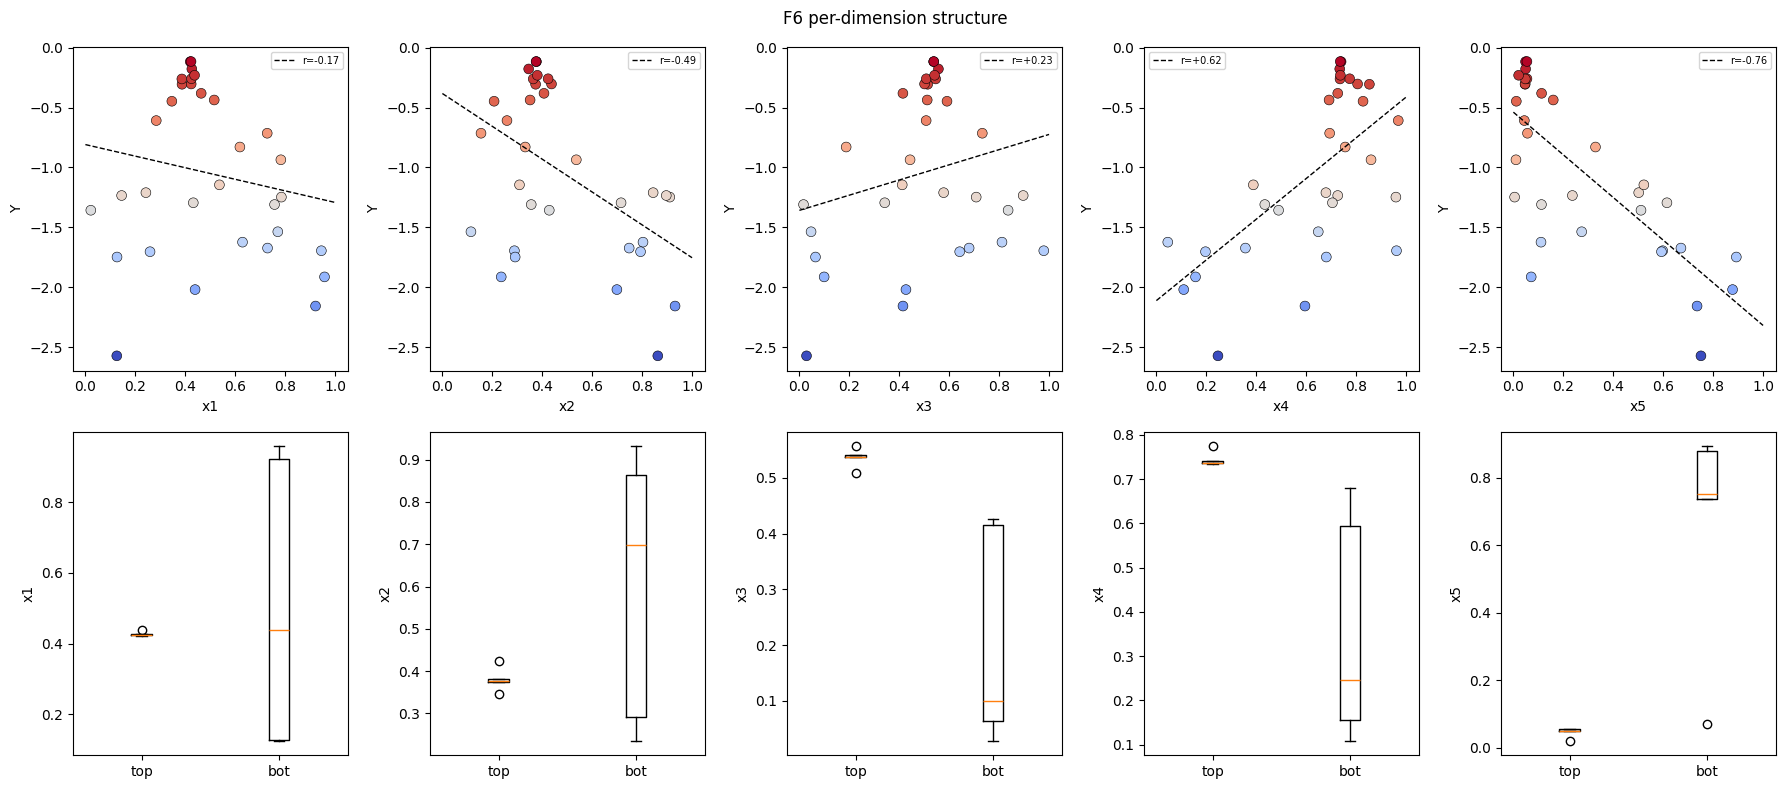

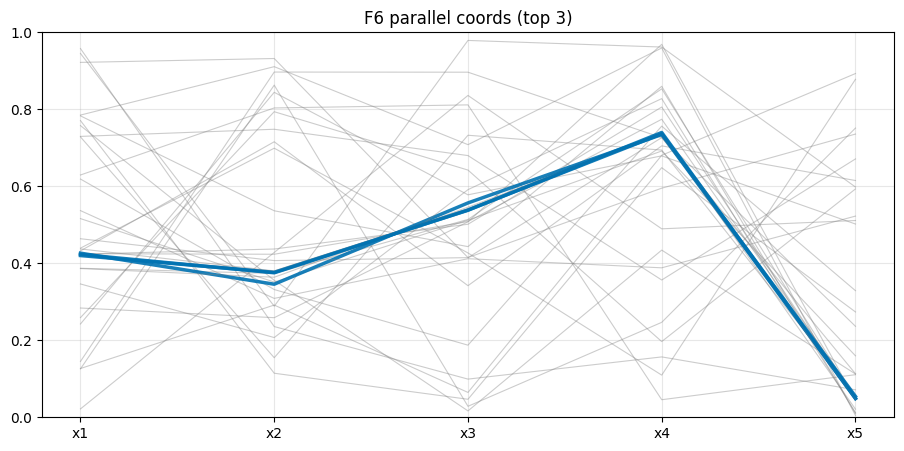

In [ ]:
# Cell B — F6 per-dim + parallel coords
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for d in range(5):
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap="coolwarm", s=50, edgecolor="k", linewidths=0.4)
    z = np.polyfit(X[:, d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax.plot(
        xs,
        np.polyval(z, xs),
        "k--",
        lw=1,
        label=f"r={np.corrcoef(X[:, d], Y)[0, 1]:+.2f}",
    )
    ax.set_xlabel(f"x{d + 1}")
    ax.set_ylabel("Y")
    ax.legend(fontsize=7)
    t5, b5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[t5, d], X[b5, d]], tick_labels=["top", "bot"])
    axes[1, d].set_ylabel(f"x{d + 1}")
plt.suptitle("F6 per-dimension structure")
plt.tight_layout()
plt.savefig("../plots/week_13/function_6_per_dim.png", dpi=110)
plt.show()
fig, ax = plt.subplots(figsize=(11, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    ax.plot(
        range(5),
        x,
        lw=2.5 if i in top3 else 0.8,
        c=COLORS[0] if i in top3 else "gray",
        alpha=0.9 if i in top3 else 0.4,
    )
ax.set_xticks(range(5))
ax.set_xticklabels([f"x{i + 1}" for i in range(5)])
ax.set(ylim=(0, 1), title="F6 parallel coords (top 3)")
ax.grid(alpha=0.3)
plt.savefig("../plots/week_13/function_6_parallel.png", dpi=110)
plt.show()


In [ ]:
# Cell C — F6 feature importance robustness
rf_all = (
    RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0)
    .fit(X, Y)
    .feature_importances_
)
rf_nb = (
    RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0)
    .fit(np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax()))
    .feature_importances_
)
lin = np.abs(LinearRegression().fit(X, Y).coef_)
lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(5)])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(5):
    print(
        f"x{d + 1}    {rf_all[d]:.3f}    {rf_nb[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}"
    )


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.079    0.077        0.206   0.173
x2    0.084    0.088        0.167   0.487
x3    0.045    0.049        0.078   0.228
x4    0.498    0.497        0.196   0.621
x5    0.293    0.289        0.352   0.757


In [ ]:
# Cell D — F6 model grid (ARD GPs + NN; RBF-ARD checked for the pathology that ejected it in W12)
from sklearn.gaussian_process.kernels import ConstantKernel
import nn_models as nm

cv = LeaveOneOut()


def fg(name, est, grid):
    g = GridSearchCV(
        est, grid, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=1
    ).fit(X, Y)
    return name, -g.best_score_, g.best_estimator_


results = [
    fg("Ridge", Ridge(), {"alpha": [0.01, 0.1, 1, 10, 100]}),
    fg(
        "KNN",
        KNeighborsRegressor(),
        {"n_neighbors": [2, 3, 5, 7], "weights": ["uniform", "distance"]},
    ),
    fg(
        "RF",
        RandomForestRegressor(random_state=0),
        {"max_depth": [2, 3, 5, None], "n_estimators": [50, 100, 200]},
    ),
    fg("SVR", SVR(kernel="rbf"), {"C": [0.1, 1, 10, 100], "gamma": ["scale", "auto"]}),
    fg(
        "GB",
        GradientBoostingRegressor(random_state=0),
        {
            "max_depth": [2, 3, 5],
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.3],
        },
    ),
]
gps = {}
for nm_, k in [
    ("GP-Matern05", ConstantKernel() * Matern(0.3, nu=0.5)),
    ("GP-Matern15-ARD", ConstantKernel() * Matern([0.3] * 5, nu=1.5)),
    ("GP-Matern25-iso", ConstantKernel() * Matern(0.3, nu=2.5)),
    ("GP-Matern25-ARD", ConstantKernel() * Matern([0.3] * 5, nu=2.5)),
    ("GP-RBF-ARD", ConstantKernel() * RBF([0.3] * 5)),
]:
    gp = GaussianProcessRegressor(
        kernel=k, normalize_y=True, alpha=1e-10, n_restarts_optimizer=4, random_state=0
    )
    s = -cross_val_score(
        gp, X, Y, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=1
    ).mean()
    results.append((nm_, s, gp.fit(X, Y)))
    gps[nm_] = results[-1][2]
results.append(
    ("NN", nm.load_nn(N, models_dir="../models/week_13")[1]["cv_rmse"], None)
)
print(f"{'Model':>16} {'LOO':>8}  vs base={baseline:.4f}")
for name, rmse, est in results:
    print(f"  {name:>14} {rmse:>8.4f}  {'OK' if rmse < baseline else 'x'}")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 2 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 2 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

           Model      LOO  vs base=0.6826
           Ridge   0.3524  OK
             KNN   0.2366  OK
              RF   0.2487  OK
             SVR   0.1392  OK
              GB   0.2322  OK
     GP-Matern05   0.1440  OK
  GP-Matern15-ARD   0.2516  OK
  GP-Matern25-iso   0.3382  OK
  GP-Matern25-ARD   0.3411  OK
      GP-RBF-ARD   0.5247  OK
              NN   0.2904  OK


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 2 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

In [ ]:
# Cell E — F6 micro-step 3-GP consensus (RBF-ARD ejected: lengthscale collapse)
best6 = X[Y.argmax()]
ybest6 = float(Y.max())
print(
    f"RBF-ARD sanity: predicts {gps['GP-RBF-ARD'].predict((best6 + 0.003)[None])[0]:+.3f} at 0.003 from the best -> EJECTED again."
)
rng = np.random.default_rng(0)
loc = best6 + rng.normal(0, 0.004, size=(300_000, 5))
loc = np.clip(loc[np.linalg.norm(loc - best6, axis=1) <= 0.010], 0.012, 0.98)
names = ["GP-Matern15-ARD", "GP-Matern25-iso", "GP-Matern25-ARD"]
ams = []
for n in names:
    m = gps[n].predict(loc)
    i = int(m.argmax())
    ams.append(loc[i])
    print(
        f"  {n:>16} micro argmax: ({', '.join(f'{v:.4f}' for v in loc[i])}) mu={m[i]:+.4f} step={np.round(loc[i] - best6, 4)}"
    )
ams = np.array(ams)
print(f"spread: {np.round(ams.max(0) - ams.min(0), 4)}")
micro_consensus6 = ams.mean(0)
print(
    f"3-GP micro consensus: ({', '.join(f'{v:.6f}' for v in micro_consensus6)}) |Δ|={np.linalg.norm(micro_consensus6 - best6):.4f}"
)
for n in names:
    print(f"  {n} at consensus: {gps[n].predict(micro_consensus6[None])[0]:+.4f}")
print(
    f"(banked {ybest6:.4f}) — all 3 predict a new best; continues x5 up (+0.006), the confirmed gradient"
)


RBF-ARD sanity: predicts -1.049 at 0.003 from the best -> EJECTED again.
   GP-Matern15-ARD micro argmax: (0.4188, 0.3758, 0.5425, 0.7329, 0.0609) mu=-0.1063 step=[-0.0043  0.0005  0.0042 -0.0035  0.0066]
   GP-Matern25-iso micro argmax: (0.4255, 0.3723, 0.5348, 0.7445, 0.0565) mu=-0.0802 step=[ 0.0024 -0.0031 -0.0035  0.008   0.0022]
   GP-Matern25-ARD micro argmax: (0.4186, 0.3744, 0.5379, 0.7332, 0.0624) mu=-0.1016 step=[-0.0045 -0.0009 -0.0004 -0.0032  0.0081]
spread: [0.0069 0.0036 0.0077 0.0115 0.0059]
3-GP micro consensus: (0.420967, 0.374172, 0.538399, 0.736854, 0.059911) |Δ|=0.0062
  GP-Matern15-ARD at consensus: -0.1094
  GP-Matern25-iso at consensus: -0.1122
  GP-Matern25-ARD at consensus: -0.1068
(banked -0.1160) — all 3 predict a new best; continues x5 up (+0.006), the confirmed gradient


### F6 — Decision (final: continue the x5-up micro-gradient)

**Query: `next_query_6 = micro_consensus6` → ≈(0.421, 0.374, 0.538, 0.737, 0.060) — 3-GP micro consensus, |Δ|≈0.006 from the W12 best.**

Method: micro-scale consensus, continuing the measured gradient.

W12 finally dethroned the 6-week W6 summit by stepping x5 up at micro scale, confirming the gradient (x5=0.021→-0.231 in W11, x5=0.054→-0.116 in W12). The refit continues x5 up another +0.006 with everything else held, |Δ|≈0.006. All three healthy GPs predict a new best (-0.107 to -0.112 vs banked -0.116). RBF-ARD stays ejected (lengthscale collapse, predicts -1.05 at a point 0.003 from the best). The pit's radial law means anything larger than a micro-step loses, so this is the only credible improvement direction left.

Branch (Step 5):
- [x] 5: 3-GP micro consensus at the function's sampleable resolution.

Per-dimension justification:
- x1 ≈ 0.421, x2 ≈ 0.374, x3 ≈ 0.538, x4 ≈ 0.737 — micro consensus (≈ W12 best)
- x5 ≈ 0.060 — the measured-gradient direction (+0.006, continuing the two-week x5-up climb)


In [38]:
# Cell I — next_query_6 assignment
next_query_6 = micro_consensus6.copy()
print(f"F6 query: " + ", ".join(f"{v:.6f}" for v in next_query_6))
print("  Method: 3-GP micro consensus, x5 up (the confirmed gradient)")


F6 query: 0.420967, 0.374172, 0.538399, 0.736854, 0.059911
  Method: 3-GP micro consensus, x5 up (the confirmed gradient)


## Function 7

In [ ]:
# Cell A — F7 setup
N = 7
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(
    "Per-dim corr: "
    + ", ".join(f"r(x{i + 1},Y)={np.corrcoef(X[:, i], Y)[0, 1]:+.3f}" for i in range(6))
)
best7 = X[Y.argmax()]
labels = ["init"] * 30 + [f"W{w}" for w in range(1, 13)]
print(f"\nW12 consensus RESULT: {Y.max():.4f}, THIRD straight new best (+4.5%).")
print("Top 5 (★ = W12), |Δ| from new best:")
for i in np.argsort(Y)[::-1][:5]:
    star = " ★W12" if i == len(Y) - 1 else ""
    print(
        f"  [{labels[i]:>4}] ({', '.join(f'{v:.4f}' for v in X[i])}) Y={Y[i]:+.4f} |Δ|={np.linalg.norm(X[i] - best7):.4f}{star}"
    )
print(
    "\nx1-up gradient: W8 x1=0.053->2.33, W11 x1=0.098->2.51, W12 x1=0.135->2.62. Continue it."
)


Function 7: 42 points, 6D, best y = 2.6183
Baseline=0.7730  |  Y range [0.0027, 2.6183]
Per-dim corr: r(x1,Y)=-0.615, r(x2,Y)=-0.037, r(x3,Y)=+0.032, r(x4,Y)=-0.432, r(x5,Y)=-0.320, r(x6,Y)=+0.529

W12 consensus RESULT: 2.6183, THIRD straight new best (+4.5%).
Top 5 (★ = W12), |Δ| from new best:
  [ W12] (0.1349, 0.2708, 0.4019, 0.2101, 0.2951, 0.7748) Y=+2.6183 |Δ|=0.0000 ★W12
  [ W11] (0.0976, 0.2908, 0.3918, 0.2140, 0.3139, 0.7769) Y=+2.5056 |Δ|=0.0476
  [  W8] (0.0530, 0.2858, 0.3381, 0.2150, 0.3166, 0.7791) Y=+2.3305 |Δ|=0.1073
  [  W9] (0.0986, 0.3867, 0.5266, 0.1739, 0.3417, 0.7761) Y=+2.1727 |Δ|=0.1838
  [ W10] (0.0168, 0.3049, 0.8166, 0.1307, 0.3302, 0.7594) Y=+1.6238 |Δ|=0.4414

x1-up gradient: W8 x1=0.053->2.33, W11 x1=0.098->2.51, W12 x1=0.135->2.62. Continue it.


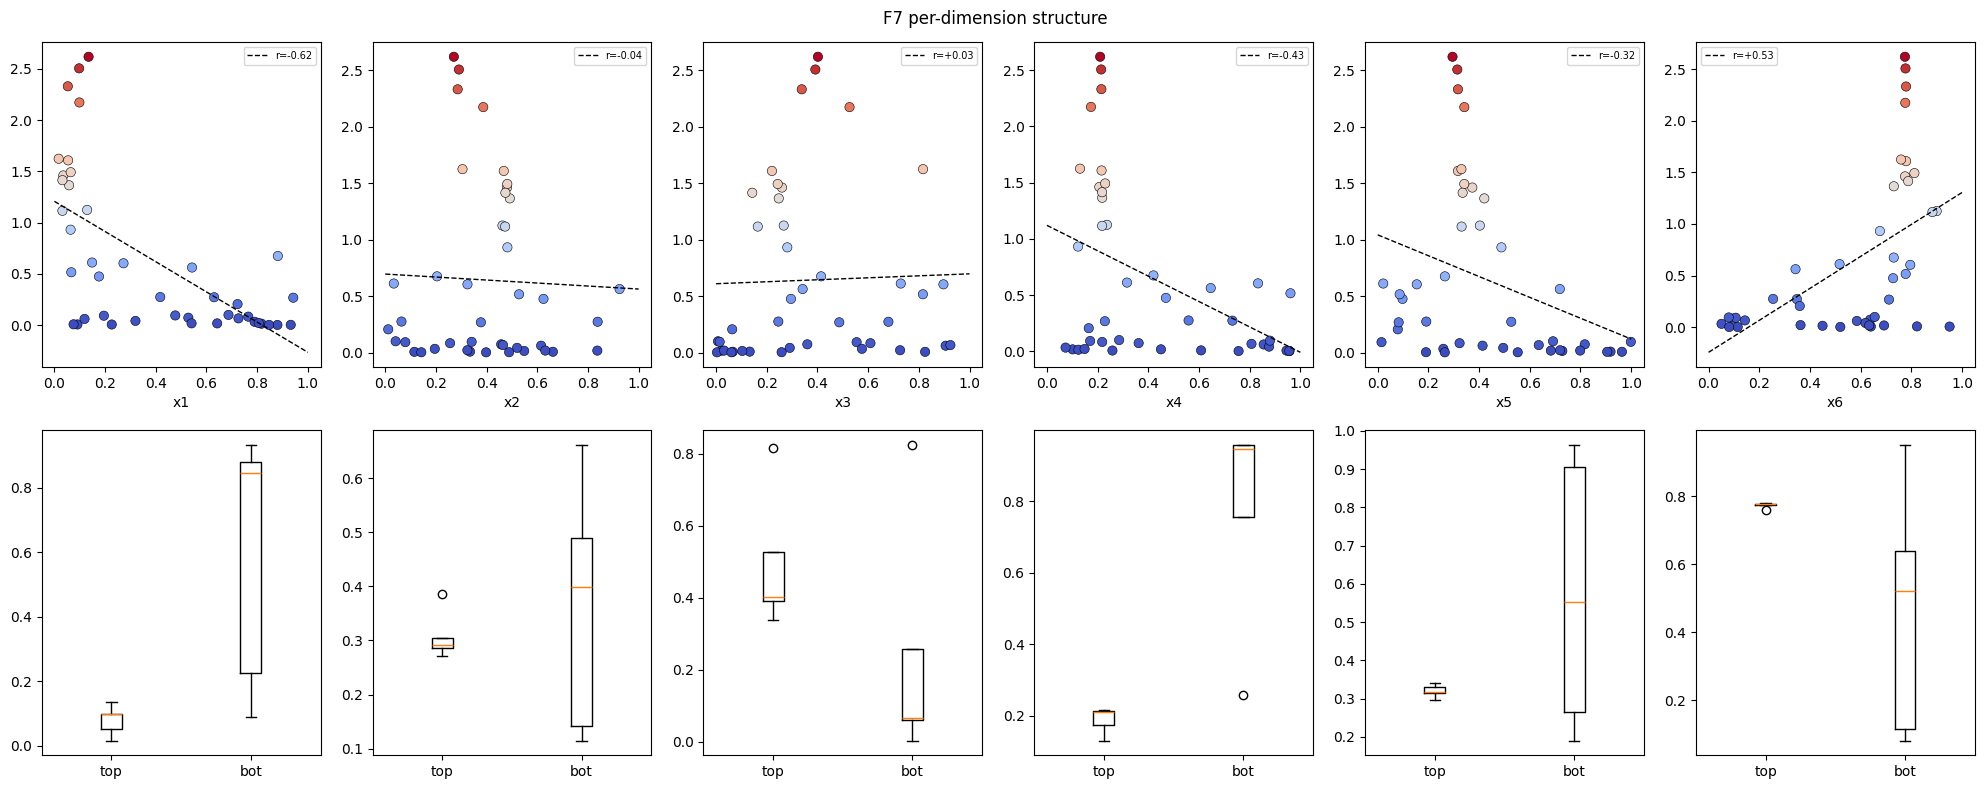

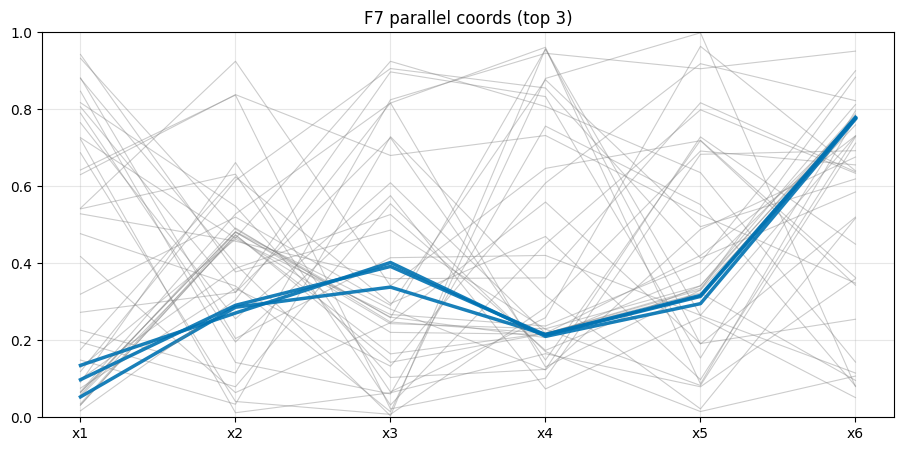

In [ ]:
# Cell B — F7 per-dim + parallel coords
fig, axes = plt.subplots(2, 6, figsize=(20, 8))
for d in range(6):
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap="coolwarm", s=45, edgecolor="k", linewidths=0.4)
    z = np.polyfit(X[:, d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax.plot(
        xs,
        np.polyval(z, xs),
        "k--",
        lw=1,
        label=f"r={np.corrcoef(X[:, d], Y)[0, 1]:+.2f}",
    )
    ax.set_xlabel(f"x{d + 1}")
    ax.legend(fontsize=7)
    t5, b5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[t5, d], X[b5, d]], tick_labels=["top", "bot"])
plt.suptitle("F7 per-dimension structure")
plt.tight_layout()
plt.savefig("../plots/week_13/function_7_per_dim.png", dpi=110)
plt.show()
fig, ax = plt.subplots(figsize=(11, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    ax.plot(
        range(6),
        x,
        lw=2.5 if i in top3 else 0.8,
        c=COLORS[0] if i in top3 else "gray",
        alpha=0.9 if i in top3 else 0.4,
    )
ax.set_xticks(range(6))
ax.set_xticklabels([f"x{i + 1}" for i in range(6)])
ax.set(ylim=(0, 1), title="F7 parallel coords (top 3)")
ax.grid(alpha=0.3)
plt.savefig("../plots/week_13/function_7_parallel.png", dpi=110)
plt.show()


In [ ]:
# Cell C — F7 feature importance robustness
rf_all = (
    RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0)
    .fit(X, Y)
    .feature_importances_
)
rf_nb = (
    RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0)
    .fit(np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax()))
    .feature_importances_
)
lin = np.abs(LinearRegression().fit(X, Y).coef_)
lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(6)])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(6):
    print(
        f"x{d + 1}    {rf_all[d]:.3f}    {rf_nb[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}"
    )


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.352    0.528        0.316   0.615
x2    0.075    0.066        0.002   0.037
x3    0.033    0.028        0.021   0.032
x4    0.171    0.125        0.230   0.432
x5    0.048    0.041        0.226   0.320
x6    0.321    0.212        0.206   0.529


In [ ]:
# Cell D — F7 model grid (ARD GPs + NN)
from sklearn.gaussian_process.kernels import ConstantKernel
import nn_models as nm

cv = LeaveOneOut()


def fg(name, est, grid):
    g = GridSearchCV(
        est, grid, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=1
    ).fit(X, Y)
    return name, -g.best_score_, g.best_estimator_


results = [
    fg("Ridge", Ridge(), {"alpha": [0.01, 0.1, 1, 10, 100]}),
    fg(
        "KNN",
        KNeighborsRegressor(),
        {"n_neighbors": [2, 3, 5, 7], "weights": ["uniform", "distance"]},
    ),
    fg(
        "RF",
        RandomForestRegressor(random_state=0),
        {"max_depth": [2, 3, 5, None], "n_estimators": [50, 100, 200]},
    ),
    fg("SVR", SVR(kernel="rbf"), {"C": [0.1, 1, 10, 100], "gamma": ["scale", "auto"]}),
    fg(
        "GB",
        GradientBoostingRegressor(random_state=0),
        {
            "max_depth": [2, 3, 5],
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.3],
        },
    ),
]
gps = {}
for nm_, k in [
    ("GP-Matern05", ConstantKernel() * Matern(0.3, nu=0.5)),
    ("GP-Matern15-ARD", ConstantKernel() * Matern([0.3] * 6, nu=1.5)),
    ("GP-Matern25-ARD", ConstantKernel() * Matern([0.3] * 6, nu=2.5)),
    ("GP-RBF-ARD", ConstantKernel() * RBF([0.3] * 6)),
]:
    gp = GaussianProcessRegressor(
        kernel=k, normalize_y=True, alpha=1e-10, n_restarts_optimizer=4, random_state=0
    )
    s = -cross_val_score(
        gp, X, Y, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=1
    ).mean()
    results.append((nm_, s, gp.fit(X, Y)))
    gps[nm_] = results[-1][2]
results.append(
    ("NN", nm.load_nn(N, models_dir="../models/week_13")[1]["cv_rmse"], None)
)
print(f"{'Model':>16} {'LOO':>8}  vs base={baseline:.4f}")
for name, rmse, est in results:
    print(f"  {name:>14} {rmse:>8.4f}  {'OK' if rmse < baseline else 'x'}")


           Model      LOO  vs base=0.7730
           Ridge   0.4729  OK
             KNN   0.2035  OK
              RF   0.2993  OK
             SVR   0.1939  OK
              GB   0.2807  OK
     GP-Matern05   0.1917  OK
  GP-Matern15-ARD   0.2414  OK
  GP-Matern25-ARD   0.2648  OK
      GP-RBF-ARD   0.3133  OK
              NN   0.3225  OK


In [ ]:
# Cell E — F7 refit 4-GP consensus, recentred on W12 best
best7 = X[Y.argmax()]
ybest7 = float(Y.max())
rng = np.random.default_rng(0)
loc = best7 + rng.normal(0, 0.04, size=(300_000, 6))
loc = np.clip(loc[np.linalg.norm(loc - best7, axis=1) <= 0.10], 0.012, 0.98)
names = ["GP-Matern05", "GP-Matern15-ARD", "GP-Matern25-ARD", "GP-RBF-ARD"]
ams = []
for n in names:
    m = gps[n].predict(loc)
    i = int(m.argmax())
    ams.append(loc[i])
    print(
        f"  {n:>16} argmax: ({', '.join(f'{v:.4f}' for v in loc[i])}) mu={m[i]:.4f} step={np.round(loc[i] - best7, 3)}"
    )
ams = np.array(ams)
print(f"spread: {np.round(ams.max(0) - ams.min(0), 3)}")
local_consensus7 = ams.mean(0)
print(
    f"4-GP consensus: ({', '.join(f'{v:.6f}' for v in local_consensus7)}) |Δ|={np.linalg.norm(local_consensus7 - best7):.4f}"
)
for n in names:
    print(f"  {n} at consensus: {gps[n].predict(local_consensus7[None])[0]:.4f}")
print(
    f"(banked {ybest7:.4f}) — 3 of 4 predict a new best; continues x1-up (+0.019), the thrice-validated gradient"
)


       GP-Matern05 argmax: (0.1350, 0.2747, 0.4037, 0.2034, 0.2920, 0.7800) mu=2.5913 step=[ 0.     0.004  0.002 -0.007 -0.003  0.005]
   GP-Matern15-ARD argmax: (0.1550, 0.2532, 0.4237, 0.2008, 0.2950, 0.7735) mu=2.6417 step=[ 0.02  -0.018  0.022 -0.009 -0.    -0.001]
   GP-Matern25-ARD argmax: (0.1703, 0.2472, 0.4177, 0.2100, 0.2957, 0.7710) mu=2.6550 step=[ 0.035 -0.024  0.016 -0.     0.001 -0.004]
        GP-RBF-ARD argmax: (0.1544, 0.2471, 0.3985, 0.2283, 0.2044, 0.7739) mu=2.6699 step=[ 0.02  -0.024 -0.003  0.018 -0.091 -0.001]
spread: [0.035 0.028 0.025 0.027 0.091 0.009]
4-GP consensus: (0.153662, 0.255553, 0.410900, 0.210633, 0.271749, 0.774594) |Δ|=0.0348
  GP-Matern05 at consensus: 2.4721
  GP-Matern15-ARD at consensus: 2.6143
  GP-Matern25-ARD at consensus: 2.6273
  GP-RBF-ARD at consensus: 2.6525
(banked 2.6183) — 3 of 4 predict a new best; continues x1-up (+0.019), the thrice-validated gradient


### F7 — Decision (final: fourth consensus step, x1-up continues)

**Query: `next_query_7 = local_consensus7` → ≈(0.154, 0.256, 0.411, 0.211, 0.272, 0.775) — refit 4-GP consensus, |Δ|≈0.035 from the W12 best.**

Method: the consensus machinery that produced three straight new bests (W8, W11, W12), recentred once more.

The x1-up gradient has driven every win on F7 (x1: 0.053→0.098→0.135 across the three, Y: 2.33→2.51→2.62), and the refit continues it (+0.019) with a small x2-down. Three of four GPs predict a new best (2.61-2.65 vs banked 2.6183); the rough Matern05 is cautious, the same posture it held — and lost — before the W11 and W12 wins. Risk is bounded: the second-best point (2.51) is only 0.048 away, so a miss stays in the 2.5+ zone.

Branch (Step 5):
- [x] 5: multi-GP local consensus, validated three times running on this function.

Per-dimension justification:
- x1 ≈ 0.154 — consensus (+0.019, the thrice-validated direction)
- x2 ≈ 0.256 — consensus (-0.015)
- x3 ≈ 0.411, x4 ≈ 0.211, x6 ≈ 0.775 — consensus (≈W12)
- x5 ≈ 0.272 — consensus (slight down)


In [44]:
# Cell I — next_query_7 assignment
next_query_7 = local_consensus7.copy()
print(f"F7 query: " + ", ".join(f"{v:.6f}" for v in next_query_7))
print("  Method: refit 4-GP local consensus (W12 winner recentred), x1-up continues")


F7 query: 0.153662, 0.255553, 0.410900, 0.210633, 0.271749, 0.774594
  Method: refit 4-GP local consensus (W12 winner recentred), x1-up continues


## Function 8

In [ ]:
# Cell A — F8 setup
N = 8
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(
    "Per-dim corr: "
    + ", ".join(f"r(x{i + 1},Y)={np.corrcoef(X[:, i], Y)[0, 1]:+.3f}" for i in range(8))
)
best8 = X[Y.argmax()]
labels = ["init"] * 40 + [f"W{w}" for w in range(1, 13)]
print(
    f"\nW12 ceiling-warp consensus RESULT: {Y.max():.4f}, NEW BEST. x5-up paid a third time."
)
print("Top 5 (★ = W12):")
for i in np.argsort(Y)[::-1][:5]:
    star = " ★W12" if i == len(Y) - 1 else ""
    print(
        f"  [{labels[i]:>4}] ({', '.join(f'{v:.3f}' for v in X[i])}) Y={Y[i]:.4f}{star}"
    )
print(
    "\nx5 ladder (monotone): 0.50->9.868, 0.67->9.911, 0.72->9.935, 0.80->9.940. x6=0.741 in every top point."
)
C_CEIL = 10.5
Z = np.log(C_CEIL - Y)
A_ = np.column_stack([np.ones(len(X)), X, X**2])
co, *_ = np.linalg.lstsq(A_, Z, rcond=None)
r2 = 1 - ((Z - A_ @ co) ** 2).sum() / ((Z - Z.mean()) ** 2).sum()
print(
    f"Ceiling transform ln({C_CEIL}-Y) R²={r2:.3f} (still strong with the new point)."
)


Function 8: 52 points, 8D, best y = 9.9400
Baseline=1.2009  |  Y range [5.5922, 9.9400]
Per-dim corr: r(x1,Y)=-0.753, r(x2,Y)=-0.435, r(x3,Y)=-0.773, r(x4,Y)=-0.317, r(x5,Y)=+0.083, r(x6,Y)=+0.367, r(x7,Y)=-0.569, r(x8,Y)=+0.252

W12 ceiling-warp consensus RESULT: 9.9400, NEW BEST. x5-up paid a third time.
Top 5 (★ = W12):
  [ W12] (0.110, 0.182, 0.128, 0.147, 0.801, 0.739, 0.172, 0.639) Y=9.9400 ★W12
  [ W11] (0.122, 0.188, 0.129, 0.173, 0.724, 0.741, 0.172, 0.619) Y=9.9345
  [  W6] (0.155, 0.201, 0.075, 0.216, 0.672, 0.741, 0.180, 0.616) Y=9.9112
  [  W9] (0.089, 0.206, 0.063, 0.243, 0.696, 0.741, 0.194, 0.662) Y=9.9106
  [ W10] (0.168, 0.215, 0.083, 0.222, 0.687, 0.741, 0.225, 0.642) Y=9.9091

x5 ladder (monotone): 0.50->9.868, 0.67->9.911, 0.72->9.935, 0.80->9.940. x6=0.741 in every top point.
Ceiling transform ln(10.5-Y) R²=0.980 (still strong with the new point).


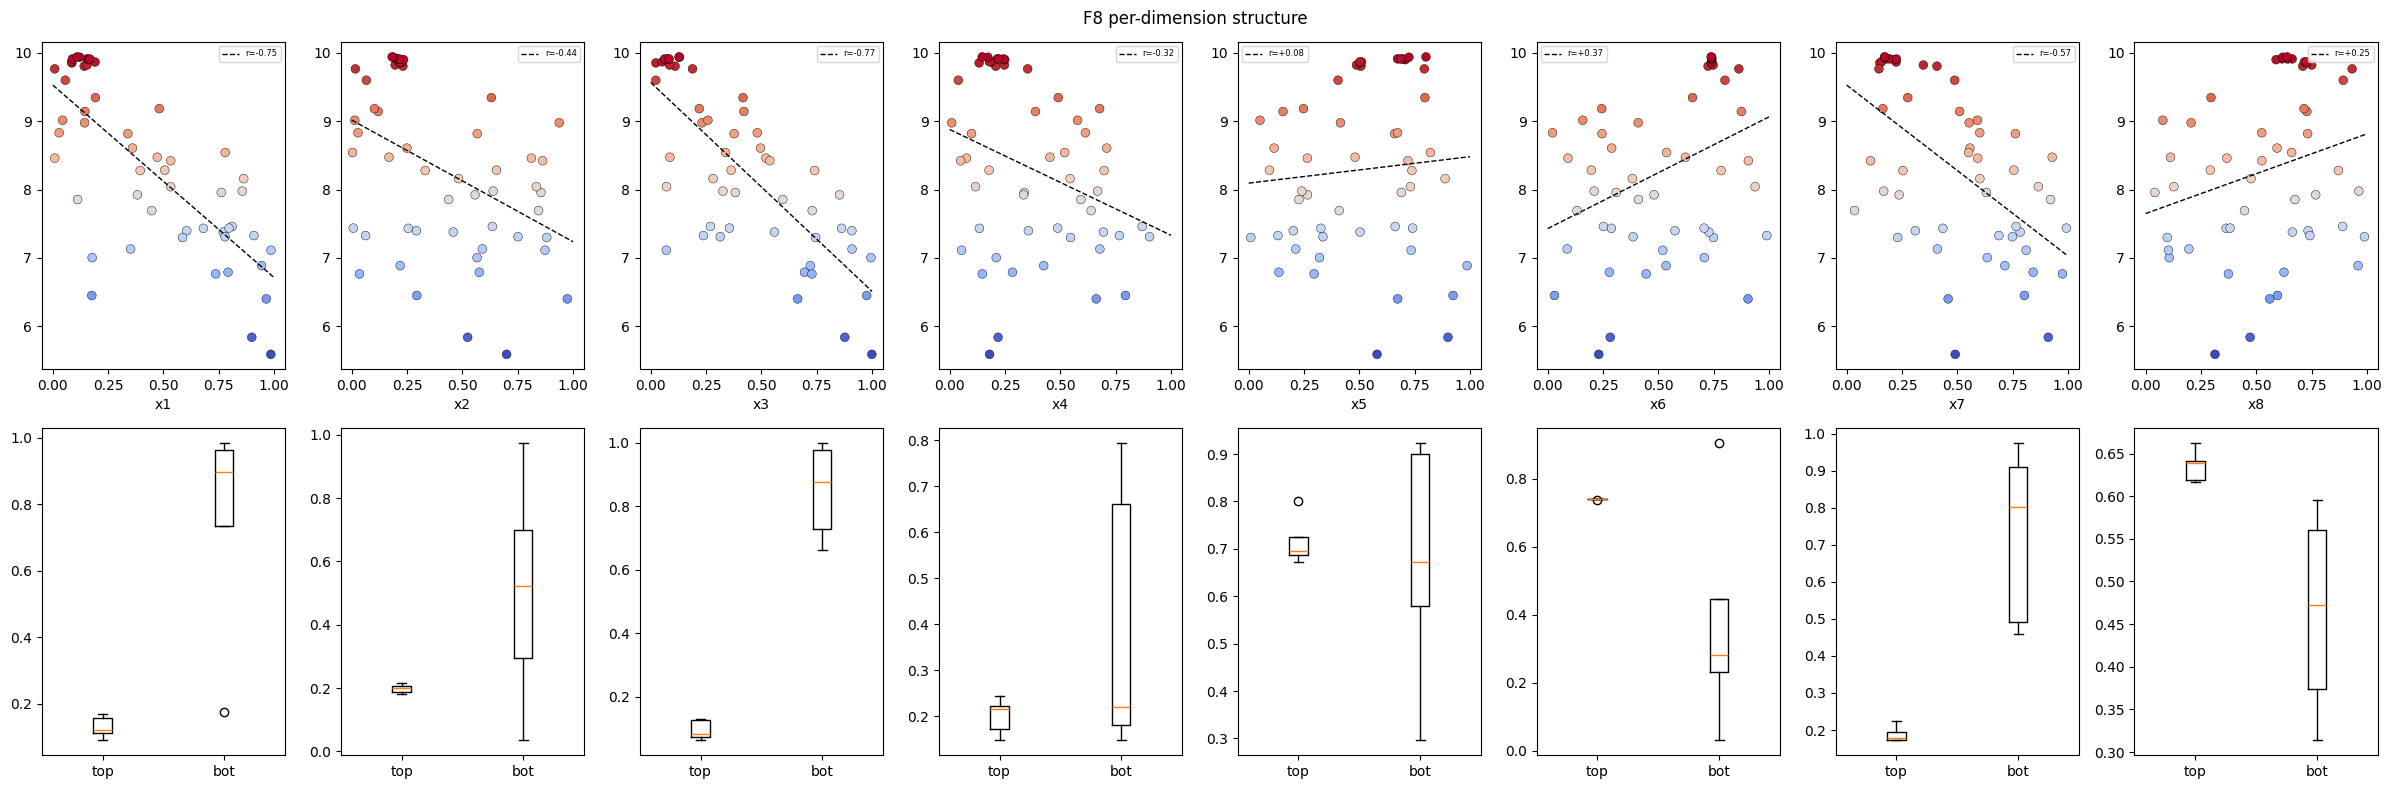

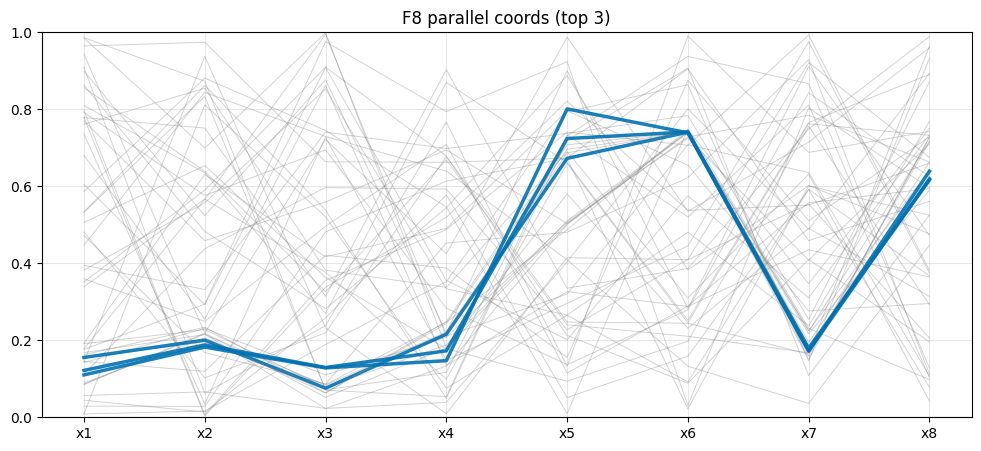

In [ ]:
# Cell B — F8 per-dim + parallel coords
fig, axes = plt.subplots(2, 8, figsize=(24, 8))
for d in range(8):
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap="coolwarm", s=40, edgecolor="k", linewidths=0.3)
    z = np.polyfit(X[:, d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax.plot(
        xs,
        np.polyval(z, xs),
        "k--",
        lw=1,
        label=f"r={np.corrcoef(X[:, d], Y)[0, 1]:+.2f}",
    )
    ax.set_xlabel(f"x{d + 1}")
    ax.legend(fontsize=6)
    t5, b5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[t5, d], X[b5, d]], tick_labels=["top", "bot"])
plt.suptitle("F8 per-dimension structure")
plt.tight_layout()
plt.savefig("../plots/week_13/function_8_per_dim.png", dpi=110)
plt.show()
fig, ax = plt.subplots(figsize=(12, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    ax.plot(
        range(8),
        x,
        lw=2.5 if i in top3 else 0.7,
        c=COLORS[0] if i in top3 else "gray",
        alpha=0.9 if i in top3 else 0.35,
    )
ax.set_xticks(range(8))
ax.set_xticklabels([f"x{i + 1}" for i in range(8)])
ax.set(ylim=(0, 1), title="F8 parallel coords (top 3)")
ax.grid(alpha=0.3)
plt.savefig("../plots/week_13/function_8_parallel.png", dpi=110)
plt.show()


In [ ]:
# Cell C — F8 feature importance robustness
rf_all = (
    RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0)
    .fit(X, Y)
    .feature_importances_
)
rf_nb = (
    RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0)
    .fit(np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax()))
    .feature_importances_
)
lin = np.abs(LinearRegression().fit(X, Y).coef_)
lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(8)])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(8):
    print(
        f"x{d + 1}    {rf_all[d]:.3f}    {rf_nb[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}"
    )


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.494    0.494        0.258   0.753
x2    0.036    0.027        0.081   0.435
x3    0.333    0.340        0.365   0.773
x4    0.013    0.013        0.046   0.317
x5    0.017    0.016        0.003   0.083
x6    0.022    0.022        0.017   0.367
x7    0.076    0.079        0.208   0.569
x8    0.009    0.009        0.023   0.252


In [ ]:
# Cell D — F8 model grid: raw + ceiling-warped GPs + NN
from sklearn.gaussian_process.kernels import ConstantKernel
import nn_models as nm

cv = LeaveOneOut()
C_CEIL = 10.5
Z = np.log(C_CEIL - Y)


def fg(name, est, grid):
    g = GridSearchCV(
        est, grid, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=1
    ).fit(X, Y)
    return name, -g.best_score_, g.best_estimator_


results = [
    fg("Ridge", Ridge(), {"alpha": [0.01, 0.1, 1, 10, 100]}),
    fg(
        "KNN",
        KNeighborsRegressor(),
        {"n_neighbors": [2, 3, 5, 7], "weights": ["uniform", "distance"]},
    ),
    fg(
        "RF",
        RandomForestRegressor(random_state=0),
        {"max_depth": [2, 3, 5, None], "n_estimators": [50, 100, 200]},
    ),
    fg("SVR", SVR(kernel="rbf"), {"C": [0.1, 1, 10, 100], "gamma": ["scale", "auto"]}),
    fg(
        "GB",
        GradientBoostingRegressor(random_state=0),
        {
            "max_depth": [2, 3, 5],
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.3],
        },
    ),
]
fits = {}
for name, kern, w in [
    ("GP-M25-iso-raw", ConstantKernel() * Matern(0.3, nu=2.5), False),
    ("GP-RBF-iso-raw", ConstantKernel() * RBF(0.3), False),
    ("GP-M15-ARD-warp", ConstantKernel() * Matern([0.3] * 8, nu=1.5), True),
    ("GP-M25-ARD-warp", ConstantKernel() * Matern([0.3] * 8, nu=2.5), True),
    ("GP-RBF-ARD-warp", ConstantKernel() * RBF([0.3] * 8), True),
]:
    tgt = Z if w else Y
    errs = []
    for i in range(len(X)):
        m = np.ones(len(X), bool)
        m[i] = False
        gi = GaussianProcessRegressor(
            kernel=kern,
            normalize_y=True,
            alpha=1e-10,
            n_restarts_optimizer=2,
            random_state=0,
        ).fit(X[m], tgt[m])
        p = gi.predict(X[i][None])[0]
        errs.append(Y[i] - (C_CEIL - np.exp(p) if w else p))
    rmse = float(np.sqrt(np.mean(np.array(errs) ** 2)))
    gf = GaussianProcessRegressor(
        kernel=kern,
        normalize_y=True,
        alpha=1e-10,
        n_restarts_optimizer=3,
        random_state=0,
    ).fit(X, tgt)
    fits[name] = (gf, w)
    results.append((name, rmse, gf))
results.append(
    ("NN", nm.load_nn(N, models_dir="../models/week_13")[1]["cv_rmse"], None)
)
print(f"{'Model':>16} {'LOO':>8}  vs base={baseline:.4f}")
for name, rmse, est in results:
    print(f"  {name:>14} {rmse:>8.4f}  {'OK' if rmse < baseline else 'x'}")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 8 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasin

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a

...

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


           Model      LOO  vs base=1.2009
           Ridge   0.2741  OK
             KNN   0.4011  OK
              RF   0.3363  OK
             SVR   0.1472  OK
              GB   0.2767  OK
  GP-M25-iso-raw   0.1095  OK
  GP-RBF-iso-raw   0.1159  OK
  GP-M15-ARD-warp   0.1295  OK
  GP-M25-ARD-warp   0.1599  OK
  GP-RBF-ARD-warp   0.3279  OK
              NN   0.3694  OK


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:
# Cell E — F8 refit ceiling-warp consensus, x6 anchored, x5-up continues
C_CEIL = 10.5


def py(name, c):
    gp, w = fits[name]
    p = gp.predict(c)
    return C_CEIL - np.exp(p) if w else p


best8 = X[Y.argmax()]
ybest8 = float(Y.max())
x6a = X[np.argsort(Y)[-4:], 5].mean()
rng = np.random.default_rng(0)
loc = best8 + rng.normal(0, 0.04, size=(300_000, 8))
loc[:, 5] = x6a + rng.normal(0, 0.002, size=len(loc))
loc = np.clip(loc[np.linalg.norm(loc - best8, axis=1) <= 0.10], 0.012, 0.98)
use = ["GP-M25-iso-raw", "GP-M15-ARD-warp", "GP-M25-ARD-warp", "GP-RBF-ARD-warp"]
ams = []
for n in use:
    m = py(n, loc)
    i = int(m.argmax())
    ams.append(loc[i])
    print(f"  {n:>16} argmax x5={loc[i, 4]:.3f} mu={m[i]:.4f}")
ams = np.array(ams)
consensus8 = ams.mean(0)
print(
    f"\n4-model consensus: ({', '.join(f'{v:.6f}' for v in consensus8)}) |Δ|={np.linalg.norm(consensus8 - best8):.4f}"
)
print(
    f"  x5={consensus8[4]:.4f} (step {consensus8[4] - best8[4]:+.3f}, the thrice-validated direction); x6 anchored {x6a:.4f}"
)
for n in use:
    print(f"  {n} at consensus: {float(py(n, consensus8[None])[0]):.4f}")
print(f"(banked {ybest8:.4f})")


    GP-M25-iso-raw argmax x5=0.803 mu=9.9476
   GP-M15-ARD-warp argmax x5=0.877 mu=9.9486
   GP-M25-ARD-warp argmax x5=0.798 mu=9.9475
   GP-RBF-ARD-warp argmax x5=0.874 mu=9.9467

4-model consensus: (0.099669, 0.179799, 0.140168, 0.108990, 0.837949, 0.739510, 0.168593, 0.651190) |Δ|=0.0568
  x5=0.8379 (step +0.037, the thrice-validated direction); x6 anchored 0.7404
  GP-M25-iso-raw at consensus: 9.9402
  GP-M15-ARD-warp at consensus: 9.9401
  GP-M25-ARD-warp at consensus: 9.9413
  GP-RBF-ARD-warp at consensus: 9.9386
(banked 9.9400)


### F8 — Decision (final query of the project: x5-up rides a fourth time)

**Query: `next_query_8 = consensus8` → ≈(0.100, 0.180, 0.140, 0.109, 0.838, 0.740, 0.169, 0.651) — refit 4-model ceiling-warp consensus, x6 anchored, |Δ|≈0.057.**

Method: the W10→W13 lineage — raw + ceiling-warped GP consensus, dominant move x5-up.

F8's x5 ladder is monotone and has paid four rounds running (x5 0.50→0.67→0.72→0.80 with Y climbing 9.868→9.940), so the final query continues it to x5≈0.838. x6 stays pinned at 0.741, its value in every top point. The ceiling structure (ln(10.5−Y) R²≈0.98) still holds, keeping the warped family as 3 of the 4 voters. All four models predict at or slightly above the bank (9.940-9.941); the plateau's history bounds any miss at ≈ -0.01.

Branch (Step 5):
- [x] 5: per-dim hybrid evolved to 4-model consensus + anchored x6.

Per-dimension justification:
- x5 ≈ 0.838 — the thrice-validated climb direction (+0.037)
- x6 = 0.740 — hard data anchor (every top point)
- x1-x4, x7, x8 — 4-model consensus (x4 -0.04 the next-largest move)


In [50]:
# Cell I — next_query_8 assignment
next_query_8 = consensus8.copy()
print(f"F8 query: " + ", ".join(f"{v:.6f}" for v in next_query_8))
print("  Method: refit 4-model ceiling-warp consensus, x6 anchored, x5-up fourth ride")


F8 query: 0.099669, 0.179799, 0.140168, 0.108990, 0.837949, 0.739510, 0.168593, 0.651190
  Method: refit 4-model ceiling-warp consensus, x6 anchored, x5-up fourth ride


## Summary — Week 13 Queries

In [ ]:
# === FINAL: All decided queries for F1-F8 ===
queries = {n: eval(f"next_query_{n}") for n in range(1, 9)}

print(f"Week 13 — All queries for submission:")
print("=" * 60)
for fn, q in queries.items():
    if q is not None:
        formatted = "-".join(f"{v:.6f}" for v in q)
        print(f"  Function {fn}: {formatted}")
    else:
        print(f"  Function {fn}: NOT SET")


Week 13 — All queries for submission:
  Function 1: 0.551199-0.512321
  Function 2: 0.695271-0.953066
  Function 3: 0.507777-0.613369-0.470253
  Function 4: 0.359205-0.419152-0.418101-0.415250
  Function 5: 0.999999-0.999999-0.999999-0.999999
  Function 6: 0.420967-0.374172-0.538399-0.736854-0.059911
  Function 7: 0.153662-0.255553-0.410900-0.210633-0.271749-0.774594
  Function 8: 0.099669-0.179799-0.140168-0.108990-0.837949-0.739510-0.168593-0.651190
